In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import math
import warnings
warnings.filterwarnings('ignore')

In [ ]:
listings=pd.read_csv('listings.csv')

In [ ]:
listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,21853,https://www.airbnb.com/rooms/21853,20250305023340,2025-03-11,city scrape,Bright and airy room,We have a quiet and sunny room with a good vie...,We live in a leafy neighbourhood with plenty o...,https://a0.muscache.com/pictures/68483181/87bc...,83531,...,4.82,4.21,4.67,NaN,f,2,0,2,0,0.26
1,30320,https://www.airbnb.com/rooms/30320,20250305023340,2025-03-10,previous scrape,Great Vacational Apartments,NaN,NaN,https://a0.muscache.com/pictures/336868/f67409...,130907,...,4.78,4.90,4.69,NaN,f,3,3,0,0,0.96
2,30959,https://www.airbnb.com/rooms/30959,20250305023340,2025-03-10,previous scrape,Beautiful loft in Madrid Center,Beautiful Loft 60m2 size just in the historica...,NaN,https://a0.muscache.com/pictures/78173471/835e...,132883,...,4.63,4.88,4.25,NaN,f,1,1,0,0,0.07
3,40916,https://www.airbnb.com/rooms/40916,20250305023340,2025-03-10,previous scrape,Holiday Apartment Madrid Center,NaN,NaN,https://a0.muscache.com/pictures/336736/c3b486...,130907,...,4.79,4.88,4.55,NaN,f,3,3,0,0,0.28
4,62423,https://www.airbnb.com/rooms/62423,20250305023340,2025-03-12,city scrape,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,INCREDIBLE HOME OF AN ARTIST SURROUNDED BY PAI...,DISTRICT WITH VERY GOOD VIBES IN THE MIDDLE OF...,https://a0.muscache.com/pictures/miso/Hosting-...,303845,...,4.85,4.97,4.58,NaN,f,3,1,2,0,2.73


In [ ]:
listings.tail()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
25283,1368985680426539467,https://www.airbnb.com/rooms/1368985680426539467,20250305023340,2025-03-12,city scrape,Acogedor y nuevo ático con gran terraza (B),"Cozy penthouse floor with large terrace, locat...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,20803102,...,NaN,NaN,NaN,NaN,f,3,3,0,0,NaN
25284,1368986418960986344,https://www.airbnb.com/rooms/1368986418960986344,20250305023340,2025-03-05,city scrape,Elegante apartamento en Madrid!,Have fun with the whole family at this stylish...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,52530675,...,NaN,NaN,NaN,NaN,f,45,45,0,0,NaN
25285,1368991577357063431,https://www.airbnb.com/rooms/1368991577357063431,20250305023340,2025-03-10,city scrape,Tropical apartment Madrid,Get away from routine at this unique and relax...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,52530675,...,NaN,NaN,NaN,NaN,f,45,45,0,0,NaN
25286,1369034696848967860,https://www.airbnb.com/rooms/1369034696848967860,20250305023340,2025-03-07,city scrape,"Cama 1 de 04, no es hinchable.",Enjoy the comfort and tranquility of this home.,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,543251626,...,NaN,NaN,NaN,NaN,f,4,0,0,4,NaN
25287,1369048563458420692,https://www.airbnb.com/rooms/1369048563458420692,20250305023340,2025-03-07,city scrape,"Cama 2 de 04, No es hinchable.",Enjoy the comfort and peace of mind of this home,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,543251626,...,NaN,NaN,NaN,NaN,f,4,0,0,4,NaN


In [ ]:
listings.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [ ]:
# Eliminamos los apartamentos sin disponibilidad
listings=listings[listings['has_availability'] != 'f']

In [ ]:
# Eliminamos a los usuarios inactivos
listings=listings.dropna(subset='host_since')

In [ ]:
# Eliminamos columnas innecesarias y columnas que han sido estimadas
listings=listings.drop(columns=['listing_url','scrape_id','last_scraped','source','name','description','neighborhood_overview','picture_url',
                                'host_id','host_url','host_name','host_since','host_location','host_about','host_thumbnail_url','host_picture_url',
                                'host_neighbourhood','host_listings_count','host_verifications','host_has_profile_pic','neighbourhood','latitude','longitude',
                                'property_type','bathrooms_text','estimated_occupancy_l365d', 'estimated_revenue_l365d',
                                'minimum_minimum_nights','maximum_minimum_nights','minimum_maximum_nights','maximum_maximum_nights',
                                'minimum_nights_avg_ntm','maximum_nights_avg_ntm','calendar_updated','has_availability', 'availability_30','availability_60','availability_90','calendar_last_scraped',
                                'number_of_reviews_l30d','first_review','last_review','license','calculated_host_listings_count','calculated_host_listings_count_entire_homes','calculated_host_listings_count_private_rooms',
                                'calculated_host_listings_count_shared_rooms','availability_eoy','number_of_reviews_ly'])

In [ ]:
listings.columns

Index(['id', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost',
       'host_total_listings_count', 'host_identity_verified',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'room_type',
       'accommodates', 'bathrooms', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable',
       'reviews_per_month'],
      dtype='object')

**Price**

In [ ]:
listings['price'] = listings['price'].str.replace('$','').str.replace(',','').astype(float)

In [ ]:
listings['price'].describe()

,price
count,19264.000000
mean,138.891144
std,433.614488
min,8.000000
25%,65.000000
50%,97.000000
75%,142.000000
max,23124.000000


In [ ]:
listings['price'].isna().sum()

np.int64(5951)

In [ ]:
listings=listings.dropna(subset='price')

In [ ]:
listings['price_log']=np.log(listings['price'])

In [ ]:
listings[['price','price_log']]

,price,price_log
0,29.0,3.367296
4,77.0,4.343805
5,66.0,4.189655
6,89.0,4.488636
7,173.0,5.153292
...,...,...
25283,103.0,4.634729
25284,100.0,4.605170
25285,66.0,4.189655
25286,16.0,2.772589


**Host Response Time**

In [ ]:
listings['host_response_time'].value_counts()

,count
host_response_time,
within an hour,13294
within a few hours,2401
within a day,1490
a few days or more,757


In [ ]:
print(listings['host_response_time'].isna().sum())

1322


In [ ]:
print(listings['id'][listings['host_response_time'].isnull()])

0                      21853
9                      84719
73                    281224
80                    752424
81                    752883
                ...         
25257    1369061126015725584
25275    1368920151972556742
25277    1368952886008952150
25286    1369034696848967860
25287    1369048563458420692
Name: id, Length: 1322, dtype: int64


In [ ]:
# Esta variable sale del detalle del host en Airbnb. Los usuarios sin valores para esta variable no tienen detalle.
# Crear categoría nueve que implique no tener esta información.
mapping = {'within an hour': 1,'within a few hours': 2,'within a day': 3,'a few days or more': 4}
listings['host_response_time'] = listings['host_response_time'].map(mapping).fillna(0).astype(int)

**Host Response Rate**

In [ ]:
listings['host_response_rate'].value_counts()

,count
host_response_rate,
100%,12168
99%,886
98%,577
92%,398
0%,388
...,...
4%,1
61%,1
15%,1


In [ ]:
# El valor coincide con la variable 'host_response_time'
print(listings['host_response_rate'].isna().sum())

1322


In [ ]:
# Los ids mostrados coinciden con los de la variable 'host_response_rate'
print(listings['id'][listings['host_response_rate'].isnull()])

0                      21853
9                      84719
73                    281224
80                    752424
81                    752883
                ...         
25257    1369061126015725584
25275    1368920151972556742
25277    1368952886008952150
25286    1369034696848967860
25287    1369048563458420692
Name: id, Length: 1322, dtype: int64


In [ ]:
# Imputamos con el 0% los valores nulos como en el caso anterior
listings['host_response_rate']=listings['host_response_rate'].fillna('0%')
listings['host_response_rate'] = listings['host_response_rate'].str.replace('%','').astype(int)

**Host Acceptance Rate**

In [ ]:
listings['host_acceptance_rate'].value_counts()

,count
host_acceptance_rate,
100%,7150
99%,2614
98%,1217
0%,666
97%,625
...,...
31%,5
26%,5
2%,5


In [ ]:
print(listings['host_acceptance_rate'].isna().sum())

781


In [ ]:
print(listings['id'][listings['host_acceptance_rate'].isnull()])

11                    595055
53                    721377
81                    752883
101                   793622
147                   867629
                ...         
25257    1369061126015725584
25275    1368920151972556742
25277    1368952886008952150
25286    1369034696848967860
25287    1369048563458420692
Name: id, Length: 781, dtype: int64


In [ ]:
# Imputamos con el 0% los valores nulos como en el caso anterior
listings['host_acceptance_rate']=listings['host_acceptance_rate'].fillna('0%')
listings['host_acceptance_rate'] = listings['host_acceptance_rate'].str.replace('%','').astype(int)

**Host is superhost**

In [ ]:
listings['host_is_superhost'].value_counts()

,count
host_is_superhost,
f,13331
t,5241


In [ ]:
print(listings['host_is_superhost'].isna().sum())

692


In [ ]:
print(listings['id'][listings['host_is_superhost'].isnull()])

7                      72150
10                     86042
26                    196197
42                    205199
153                   888289
                ...         
24898    1359215945970823005
24911    1359333582287242240
25017    1360922108851440354
25153    1366660843511101353
25220    1368049172456648908
Name: id, Length: 692, dtype: int64


In [ ]:
listings['host_is_superhost'] = listings['host_is_superhost'].replace({'t': 1, 'f': 0})

In [ ]:
# El hecho de ser un superhost puede ser algo representativo. Imputamos los valores nulos con la media
listings['host_is_superhost']=listings['host_is_superhost'].fillna(listings['host_is_superhost'].mode()[0])

**Host total listings count**

In [ ]:
listings['host_total_listings_count'].describe()

,host_total_listings_count
count,19264.000000
mean,73.585963
std,212.573769
min,1.000000
25%,2.000000
50%,7.000000
75%,43.000000
max,8554.000000


In [ ]:
print(listings['host_total_listings_count'].isna().sum())

0


**Host identity verified**

In [ ]:
listings['host_identity_verified'].value_counts()

,count
host_identity_verified,
t,18137
f,1127


In [ ]:
print(listings['host_identity_verified'].isna().sum())

0


In [ ]:
# El 88% de los usuarios están verificado. Variable descompensada, por lo que se decide eliminarla y reducir dimensionalidad.
listings = listings.drop(columns='host_identity_verified')

**Neighbourhood_group_cleansed**

In [ ]:
listings['neighbourhood_group_cleansed'].value_counts()

,count
neighbourhood_group_cleansed,
Centro,8290
Salamanca,1291
Tetuán,1278
Chamberí,1207
Arganzuela,1004
Retiro,739
Carabanchel,683
Chamartín,659
Ciudad Lineal,624


In [ ]:
print(listings['neighbourhood_group_cleansed'].isna().sum())

0


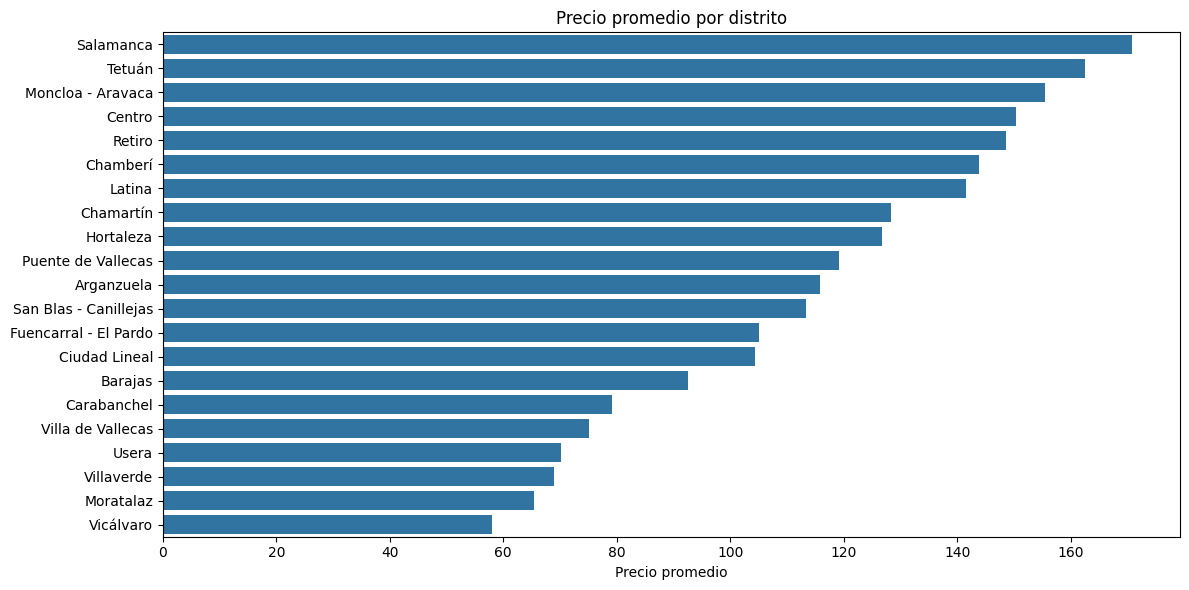

In [ ]:
mean_price_by_district = listings.groupby('neighbourhood_group_cleansed')['price'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(
    y=mean_price_by_district.index,
    x=mean_price_by_district.values,
)
plt.xlabel('Precio promedio')
plt.ylabel('')
plt.title('Precio promedio por distrito')
plt.tight_layout()
plt.show()

In [ ]:
listings = pd.get_dummies(listings, prefix='distrito', columns=['neighbourhood_group_cleansed'], drop_first=True)

**Room Type**

In [ ]:
listings['room_type'].value_counts()

,count
room_type,
Entire home/apt,13864
Private room,5232
Shared room,113
Hotel room,55


In [ ]:
print(listings['room_type'].isna().sum())

0


In [ ]:
# Obtenemos los dummies para la variable
listings = pd.get_dummies(listings, prefix='rt', columns=['room_type'], drop_first=True)

**Accommodates**

In [ ]:
listings['accommodates'].describe()

,accommodates
count,19264.000000
mean,3.301755
std,1.932932
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,16.000000


In [ ]:
print(listings['accommodates'].isna().sum())

0


**Bathrooms**

In [ ]:
listings['bathrooms'].describe()

,bathrooms
count,19250.000000
mean,1.286883
std,0.628535
min,0.000000
25%,1.000000
50%,1.000000
75%,1.500000
max,15.000000


In [ ]:
print(listings['bathrooms'].isna().sum())

14


In [ ]:
print(listings['id'][listings['bathrooms'].isnull()])

225                  1126038
16928    1055059604278851622
17095    1061383842209093357
17154    1062947568687518621
17156    1063027411298743057
17875    1095885326545439819
18332    1122980800648546483
19202    1151639640005877879
19341    1154804971460556557
20234    1184793504625829151
20271    1187658953522221199
21074    1217999363447466312
22636    1285391200025909250
23968    1333329797222099128
Name: id, dtype: int64


In [ ]:
listings.loc[listings['id'] == 1126038, 'bathrooms'] = 1
listings.loc[listings['id'] == 1055059604278851622, 'bathrooms'] = 1
listings.loc[listings['id'] == 1061383842209093357, 'bathrooms'] = 1
listings.loc[listings['id'] == 1062947568687518621, 'bathrooms'] = 1
listings.loc[listings['id'] == 1063027411298743057, 'bathrooms'] = 1
listings.loc[listings['id'] == 1095885326545439819, 'bathrooms'] = 0
listings.loc[listings['id'] == 1122980800648546483, 'bathrooms'] = 1
listings.loc[listings['id'] == 1151639640005877879, 'bathrooms'] = 1
listings.loc[listings['id'] == 1154804971460556557, 'bathrooms'] = 1
listings.loc[listings['id'] == 1184793504625829151, 'bathrooms'] = 1
listings.loc[listings['id'] == 1187658953522221199, 'bathrooms'] = 1
listings.loc[listings['id'] == 1217999363447466312, 'bathrooms'] = 1
listings.loc[listings['id'] == 1285391200025909250, 'bathrooms'] = 1
listings=listings[listings['id'] != 1333329797222099128 ]

**Bedrooms**

In [ ]:
listings['bedrooms'].describe()

,bedrooms
count,19239.000000
mean,1.385155
std,0.941473
min,0.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,25.000000


In [ ]:
print(listings['bedrooms'].isna().sum())

24


In [ ]:
print(listings['id'][listings['bedrooms'].isnull()])

7597                43633259
8251                48130655
10376     623074627213162993
20059    1176881854714457011
20060    1176884746152975962
20061    1176885269566580674
20068    1176887700183507676
20371    1192042757924199562
22319    1269700197244281715
23777    1322567264800622761
23819    1327419239168043947
23958    1333277349793430676
23961    1333281107518192375
23962    1333286174681630768
23963    1333289652497721165
23969    1333332885585891559
23970    1333336204150047516
23985    1333348641824534861
24142    1335551160361063050
24562    1349744097766646177
24700    1352544497190392224
25159    1366721466828525091
25179    1366853173044267909
25180    1366858853095347848
Name: id, dtype: int64


In [ ]:
listings.loc[listings['id'] == 43633259, 'bedrooms'] = 1
listings.loc[listings['id'] == 48130655, 'bedrooms'] = 1
listings=listings[listings['id'] != 623074627213162993 ]
listings.loc[listings['id'] == 1176881854714457011, 'bedrooms'] = 1
listings.loc[listings['id'] == 1176884746152975962, 'bedrooms'] = 1
listings.loc[listings['id'] == 1176885269566580674, 'bedrooms'] = 1
listings.loc[listings['id'] == 1176887700183507676, 'bedrooms'] = 1
listings=listings[listings['id'] != 1192042757924199562 ]
listings.loc[listings['id'] == 1269700197244281715, 'bedrooms'] = 2
listings.loc[listings['id'] == 1322567264800622761, 'bedrooms'] = 1
listings.loc[listings['id'] == 1327419239168043947, 'bedrooms'] = 1
listings.loc[listings['id'] == 1333277349793430676, 'bedrooms'] = 1
listings.loc[listings['id'] == 1333281107518192375, 'bedrooms'] = 1
listings.loc[listings['id'] == 1333286174681630768, 'bedrooms'] = 1
listings.loc[listings['id'] == 1333289652497721165, 'bedrooms'] = 1
listings.loc[listings['id'] == 1333332885585891559, 'bedrooms'] = 1
listings.loc[listings['id'] == 1333336204150047516, 'bedrooms'] = 1
listings=listings[listings['id'] != 1333348641824534861 ]
listings.loc[listings['id'] == 1335551160361063050, 'bedrooms'] = 1
listings.loc[listings['id'] == 1349744097766646177, 'bedrooms'] = 1
listings=listings[listings['id'] != 1352544497190392224 ]
listings.loc[listings['id'] == 1366721466828525091, 'bedrooms'] = 1
listings.loc[listings['id'] == 1366853173044267909, 'bedrooms'] = 1
listings.loc[listings['id'] == 1366858853095347848, 'bedrooms'] = 1

**Beds**

In [ ]:
listings['beds'].describe()

,beds
count,19240.000000
mean,1.984459
std,1.456730
min,0.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,40.000000


In [ ]:
print(listings['beds'].isna().sum())

19


In [ ]:
print(listings['id'][listings['beds'].isnull()])

225      1126038
6206    36137508
6974    40327487
6977    40205929
7014    40286024
7087    40970252
7547    42933216
7779    44543671
7780    44544624
8153    47569019
8154    47569170
8337    49170269
8400    49266868
8731    50909540
8968    51554244
8971    51558455
8972    51558636
9169    52943949
9303    53225206
Name: id, dtype: int64


In [ ]:
listings.loc[listings['id'] == 1126038, 'beds'] = 1
listings.loc[listings['id'] == 36137508, 'beds'] = 12
listings.loc[listings['id'] == 40327487, 'beds'] = 2
listings.loc[listings['id'] == 40205929, 'beds'] = 2
listings=listings[listings['id'] != 40286024 ]
listings.loc[listings['id'] == 40970252, 'beds'] = 1
listings.loc[listings['id'] == 42933216, 'beds'] = 1
listings.loc[listings['id'] == 44543671, 'beds'] = 2
listings.loc[listings['id'] == 44544624, 'beds'] = 2
listings.loc[listings['id'] == 47569019, 'beds'] = 1
listings.loc[listings['id'] == 47569170, 'beds'] = 1
listings.loc[listings['id'] == 49170269, 'beds'] = 1
listings.loc[listings['id'] == 49266868, 'beds'] = 1
listings.loc[listings['id'] == 50909540, 'beds'] = 1
listings.loc[listings['id'] == 51554244, 'beds'] = 4
listings.loc[listings['id'] == 51558455, 'beds'] = 6
listings.loc[listings['id'] == 51558636, 'beds'] = 8
listings.loc[listings['id'] == 52943949, 'beds'] = 1
listings.loc[listings['id'] == 53225206, 'beds'] = 1

**Amenities**

In [ ]:
listings['amenities']

,amenities
0,"[""Wifi"", ""Bed linens"", ""Dishes and silverware""..."
4,"[""Host greets you"", ""Dishes and silverware"", ""..."
5,"[""Paid parking off premises"", ""Window AC unit""..."
6,"[""Portable fans"", ""Paid parking off premises"",..."
7,"[""Wifi"", ""Dishes and silverware"", ""Oven"", ""Hot..."
...,...
25283,"[""Cleaning available during stay"", ""Wifi"", ""Wi..."
25284,"[""Pets allowed"", ""Kitchen"", ""TV"", ""Air conditi..."
25285,"[""Pets allowed"", ""Kitchen"", ""TV"", ""Air conditi..."
25286,"[""Wifi""]"


In [ ]:
listings[['id','amenities']]

,id,amenities
0,21853,"[""Wifi"", ""Bed linens"", ""Dishes and silverware""..."
4,62423,"[""Host greets you"", ""Dishes and silverware"", ""..."
5,70059,"[""Paid parking off premises"", ""Window AC unit""..."
6,70310,"[""Portable fans"", ""Paid parking off premises"",..."
7,72150,"[""Wifi"", ""Dishes and silverware"", ""Oven"", ""Hot..."
...,...,...
25283,1368985680426539467,"[""Cleaning available during stay"", ""Wifi"", ""Wi..."
25284,1368986418960986344,"[""Pets allowed"", ""Kitchen"", ""TV"", ""Air conditi..."
25285,1368991577357063431,"[""Pets allowed"", ""Kitchen"", ""TV"", ""Air conditi..."
25286,1369034696848967860,"[""Wifi""]"


In [ ]:
print(listings['amenities'].isna().sum())

0


In [ ]:
# Creamos variables dummies de algunas amenities
listings.loc[listings['amenities'].str.contains('Self check-in'), 'self_check_in'] = 1
listings.loc[listings['amenities'].str.contains('Air conditioning'), 'air_conditioning'] = 1
listings.loc[listings['amenities'].str.contains('Amazon Prime|Apple TV|Game console|PS|XBOX|Xbox|xbox|Netflix|Projector and screen|Smart TV|HBO'), 'high_end_electronics'] = 1
listings.loc[listings['amenities'].str.contains('BBQ grill|Fire pit|Propane barbeque'), 'bbq'] = 1
listings.loc[listings['amenities'].str.contains('Kitchen|Refirgerator|Microwave|Cooking basics|Dishes and silverware|Coffee maker'), 'kitchen_and_else'] = 1
listings.loc[listings['amenities'].str.contains('Bed linens'), 'bed_linen'] = 1
listings.loc[listings['amenities'].str.contains('Breakfast'), 'breakfast'] = 1
listings.loc[listings['amenities'].str.contains('TV'), 'tv'] = 1
listings.loc[listings['amenities'].str.contains('Wifi|wifi'), 'wifi'] = 1
listings.loc[listings['amenities'].str.contains('Dishwasher|Dryer|Washer|dryer|washer'), 'white_goods'] = 1
listings.loc[listings['amenities'].str.contains('Elevator'), 'elevator'] = 1
listings.loc[listings['amenities'].str.contains('Exercise equipment|Gym|gym'), 'gym'] = 1
listings.loc[listings['amenities'].str.contains('parking'), 'parking'] = 1
listings.loc[listings['amenities'].str.contains('balcony|Balcony|Patio|patio|Garden'), 'outdoor_space'] = 1
listings.loc[listings['amenities'].str.contains('Hot tub|hot tub|Sauna|sauna|Pool|pool'), 'hot_tub_sauna_or_pool'] = 1
listings.loc[listings['amenities'].str.contains('Long term stays allowed'), 'long_term_stays'] = 1
listings.loc[listings['amenities'].str.contains('Pets|Pets allowed'), 'pets_allowed'] = 1
listings.loc[listings['amenities'].str.contains('security'), 'security'] = 1

In [ ]:
listings['self_check_in']=listings['self_check_in'].fillna(0)
listings['air_conditioning']=listings['air_conditioning'].fillna(0)
listings['high_end_electronics']=listings['high_end_electronics'].fillna(0)
listings['bbq']=listings['bbq'].fillna(0)
listings['kitchen_and_else']=listings['kitchen_and_else'].fillna(0)
listings['bed_linen']=listings['bed_linen'].fillna(0)
listings['breakfast']=listings['breakfast'].fillna(0)
listings['tv']=listings['tv'].fillna(0)
listings['wifi']=listings['wifi'].fillna(0)
listings['white_goods']=listings['white_goods'].fillna(0)
listings['elevator']=listings['elevator'].fillna(0)
listings['gym']=listings['gym'].fillna(0)
listings['parking']=listings['parking'].fillna(0)
listings['outdoor_space']=listings['outdoor_space'].fillna(0)
listings['hot_tub_sauna_or_pool']=listings['hot_tub_sauna_or_pool'].fillna(0)
listings['long_term_stays']=listings['long_term_stays'].fillna(0)
listings['pets_allowed']=listings['pets_allowed'].fillna(0)
listings['security']=listings['security'].fillna(0)

In [ ]:
listings=listings.drop(columns='amenities')

**Minimum nights**

In [ ]:
listings['minimum_nights'].describe()

,minimum_nights
count,19258.000000
mean,7.741562
std,20.073796
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,700.000000


In [ ]:
print(listings['minimum_nights'].isna().sum())

0


**Maximum nights**

In [ ]:
listings['maximum_nights'].describe()

,maximum_nights
count,19258.000000
mean,512.189687
std,397.635028
min,1.000000
25%,360.000000
50%,365.000000
75%,1125.000000
max,1825.000000


In [ ]:
print(listings['maximum_nights'].isna().sum())

0


**Availability_365**

In [ ]:
listings['availability_365'].describe()

,availability_365
count,19258.000000
mean,173.192336
std,126.621141
min,0.000000
25%,49.000000
50%,179.000000
75%,288.750000
max,365.000000


In [ ]:
print(listings['availability_365'].isna().sum())

0


**Instant bookable**

In [ ]:
listings['instant_bookable'].value_counts()

,count
instant_bookable,
f,10192
t,9066


In [ ]:
print(listings['instant_bookable'].isna().sum())

0


In [ ]:
listings['instant_bookable'] = listings['instant_bookable'].replace({'t': 1, 'f': 0})

**Number of reviews**

In [ ]:
listings['number_of_reviews'].describe()

,number_of_reviews
count,19258.000000
mean,55.788815
std,96.157891
min,0.000000
25%,2.000000
50%,16.000000
75%,66.000000
max,1080.000000


In [ ]:
print(listings['number_of_reviews'].isna().sum())

0


**Number of reviews ltm**

In [ ]:
listings['number_of_reviews_ltm'].describe()

,number_of_reviews_ltm
count,19258.000000
mean,17.581628
std,23.342280
min,0.000000
25%,1.000000
50%,7.000000
75%,27.000000
max,263.000000


In [ ]:
print(listings['number_of_reviews_ltm'].isna().sum())

0


**Review scores rating**

In [ ]:
listings['review_scores_rating'].describe()

,review_scores_rating
count,16082.000000
mean,4.646278
std,0.469745
min,1.000000
25%,4.550000
50%,4.760000
75%,4.910000
max,5.000000


In [ ]:
print(listings['review_scores_rating'].isna().sum())

3176


In [ ]:
listings['review_scores_rating'] = listings['review_scores_rating'].fillna(0)

**Review scores accuracy**

In [ ]:
listings['review_scores_accuracy'].describe()

,review_scores_accuracy
count,16082.000000
mean,4.697327
std,0.431591
min,1.000000
25%,4.630000
50%,4.810000
75%,4.930000
max,5.000000


In [ ]:
print(listings['review_scores_accuracy'].isna().sum())

3176


In [ ]:
listings['review_scores_accuracy'] = listings['review_scores_accuracy'].fillna(0)

**Review scores cleanliness**

In [ ]:
listings['review_scores_cleanliness'].describe()

,review_scores_cleanliness
count,16081.000000
mean,4.686618
std,0.428334
min,1.000000
25%,4.600000
50%,4.800000
75%,4.930000
max,5.000000


In [ ]:
print(listings['review_scores_cleanliness'].isna().sum())

3177


In [ ]:
listings['review_scores_cleanliness'] = listings['review_scores_cleanliness'].fillna(0)

**Review scores checkin**

In [ ]:
listings['review_scores_checkin'].describe()

,review_scores_checkin
count,16081.000000
mean,4.739554
std,0.427600
min,1.000000
25%,4.690000
50%,4.850000
75%,4.960000
max,5.000000


In [ ]:
print(listings['review_scores_checkin'].isna().sum())

3177


In [ ]:
listings['review_scores_checkin'] = listings['review_scores_checkin'].fillna(0)

**Review scores communication**

In [ ]:
listings['review_scores_communication'].describe()

,review_scores_communication
count,16082.000000
mean,4.746783
std,0.454681
min,1.000000
25%,4.710000
50%,4.880000
75%,4.980000
max,5.000000


In [ ]:
print(listings['review_scores_communication'].isna().sum())

3176


In [ ]:
listings['review_scores_communication'] = listings['review_scores_communication'].fillna(0)

**Review scores location**

In [ ]:
listings['review_scores_location'].describe()

,review_scores_location
count,16082.000000
mean,4.746568
std,0.367994
min,1.000000
25%,4.670000
50%,4.860000
75%,4.970000
max,5.000000


In [ ]:
print(listings['review_scores_location'].isna().sum())

3176


In [ ]:
listings['review_scores_location'] = listings['review_scores_location'].fillna(0)

**Review scores value**

In [ ]:
listings['review_scores_value'].describe()

,review_scores_value
count,16082.000000
mean,4.546439
std,0.497737
min,1.000000
25%,4.440000
50%,4.660000
75%,4.820000
max,5.000000


In [ ]:
print(listings['review_scores_value'].isna().sum())

3176


In [ ]:
listings['review_scores_value'] = listings['review_scores_value'].fillna(0)

**Reviews per month**

In [ ]:
listings['reviews_per_month'].describe()

,reviews_per_month
count,16082.000000
mean,2.033916
std,1.976566
min,0.010000
25%,0.560000
50%,1.460000
75%,2.960000
max,28.570000


In [ ]:
print(listings['reviews_per_month'].isna().sum())

3176


In [ ]:
listings['reviews_per_month'] = listings['reviews_per_month'].fillna(0)

**Neighbourhood cleansed**

In [ ]:
listings['neighbourhood_cleansed'].value_counts()

,count
neighbourhood_cleansed,
Embajadores,2176
Universidad,1735
Palacio,1426
Sol,1112
Justicia,995
...,...
Valdemarín,5
Fuentelareina,5
El Pardo,3


In [ ]:
print(listings['neighbourhood_cleansed'].isna().sum())

0


In [ ]:
listings=listings.drop(columns='neighbourhood_cleansed')

---

In [ ]:
listings.columns = listings.columns.str.replace(' ','_')
listings.columns = listings.columns.str.replace('-','_')
listings.columns = listings.columns.map(lambda x: x.lower())

In [ ]:
listings[listings.select_dtypes('bool').columns] = listings.select_dtypes('bool').astype(int)

In [ ]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19258 entries, 0 to 25287
Data columns (total 67 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              19258 non-null  int64  
 1   host_response_time              19258 non-null  int64  
 2   host_response_rate              19258 non-null  int64  
 3   host_acceptance_rate            19258 non-null  int64  
 4   host_is_superhost               19258 non-null  float64
 5   host_total_listings_count       19258 non-null  float64
 6   accommodates                    19258 non-null  int64  
 7   bathrooms                       19258 non-null  float64
 8   bedrooms                        19258 non-null  float64
 9   beds                            19258 non-null  float64
 10  price                           19258 non-null  float64
 11  minimum_nights                  19258 non-null  int64  
 12  maximum_nights                  19258

In [ ]:
listings['self_check_in']=listings['self_check_in'].astype(int)
listings['air_conditioning']=listings['air_conditioning'].astype(int)
listings['high_end_electronics']=listings['high_end_electronics'].astype(int)
listings['bbq']=listings['bbq'].astype(int)
listings['kitchen_and_else']=listings['kitchen_and_else'].astype(int)
listings['bed_linen']=listings['bed_linen'].astype(int)
listings['breakfast']=listings['breakfast'].astype(int)
listings['tv']=listings['tv'].astype(int)
listings['wifi']=listings['wifi'].astype(int)
listings['white_goods']=listings['white_goods'].astype(int)
listings['elevator']=listings['elevator'].astype(int)
listings['gym']=listings['gym'].astype(int)
listings['parking']=listings['parking'].astype(int)
listings['outdoor_space']=listings['outdoor_space'].astype(int)
listings['hot_tub_sauna_or_pool']=listings['hot_tub_sauna_or_pool'].astype(int)
listings['long_term_stays']=listings['long_term_stays'].astype(int)
listings['pets_allowed']=listings['pets_allowed'].astype(int)
listings['security']=listings['security'].astype(int)

In [ ]:
listings['bathrooms']=listings['bathrooms'].astype(int)
listings['bedrooms']=listings['bedrooms'].astype(int)
listings['beds']=listings['beds'].astype(int)

In [ ]:
print(listings.isna().sum().sum())

0


**Sentiment Score**

In [ ]:
df_sentiment=pd.read_csv('sentiment_score_afinn.csv')
df_sentiment

,Unnamed: 0,listing_id,Sentiment_Score_Afinn
0,0,21853,10.030303
1,1,30320,9.859649
2,2,30959,4.875000
3,3,40916,7.571429
4,4,62423,8.805430
...,...,...,...
20053,20053,1365007887657848515,5.000000
20054,20054,1366534590465861868,5.000000
20055,20055,1366853173044267909,3.000000
20056,20056,1368304377290123314,2.000000


In [ ]:
listings = listings.merge(df_sentiment[['listing_id','Sentiment_Score_Afinn']], left_on='id', right_on='listing_id', how='left')

In [ ]:
listings=listings.drop(columns=['listing_id'])

In [ ]:
print(listings['Sentiment_Score_Afinn'].isna().sum())

3201


In [ ]:
listings['Sentiment_Score_Afinn'] = listings['Sentiment_Score_Afinn'].fillna(0)

---

In [ ]:
listings.columns

Index(['id', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost',
       'host_total_listings_count', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'price', 'minimum_nights', 'maximum_nights', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable',
       'reviews_per_month', 'price_log', 'distrito_barajas',
       'distrito_carabanchel', 'distrito_centro', 'distrito_chamartín',
       'distrito_chamberí', 'distrito_ciudad_lineal',
       'distrito_fuencarral___el_pardo', 'distrito_hortaleza',
       'distrito_latina', 'distrito_moncloa___aravaca', 'distrito_moratalaz',
       'distrito_puente_de_vallecas', 'distrito_retiro', 'distrito_salamanca',
       'distrito_san_blas___canillejas', 'distrit

---

**EDA todos los apartamentos**

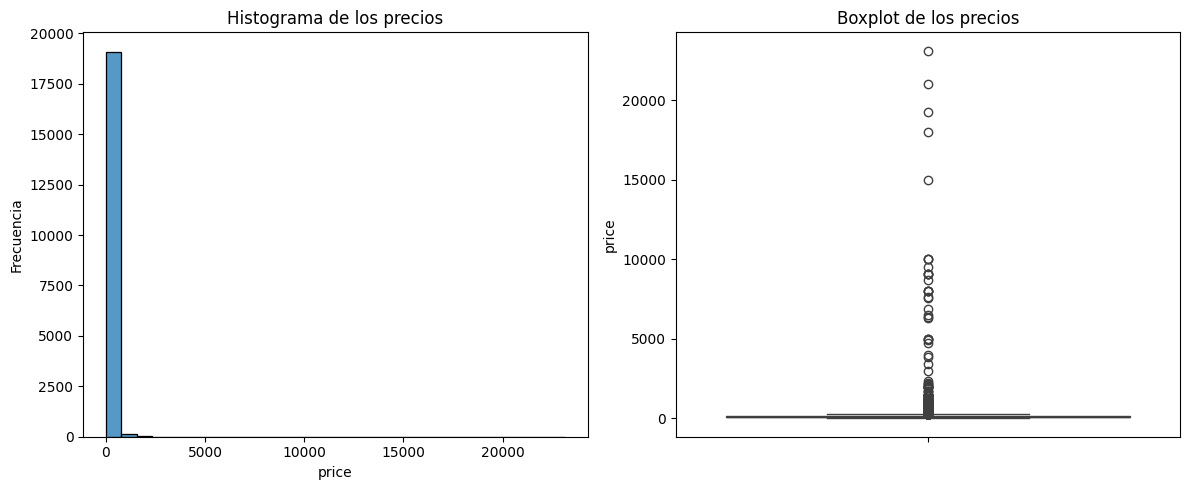

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


sns.histplot(listings['price'], bins=30, kde=False, ax=axes[0])
axes[0].set_title('Histograma de los precios')
axes[0].set_xlabel('price')
axes[0].set_ylabel('Frecuencia')

# Boxplot
sns.boxplot(y=listings['price'], ax=axes[1])
axes[1].set_title('Boxplot de los precios')
axes[1].set_ylabel('price')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

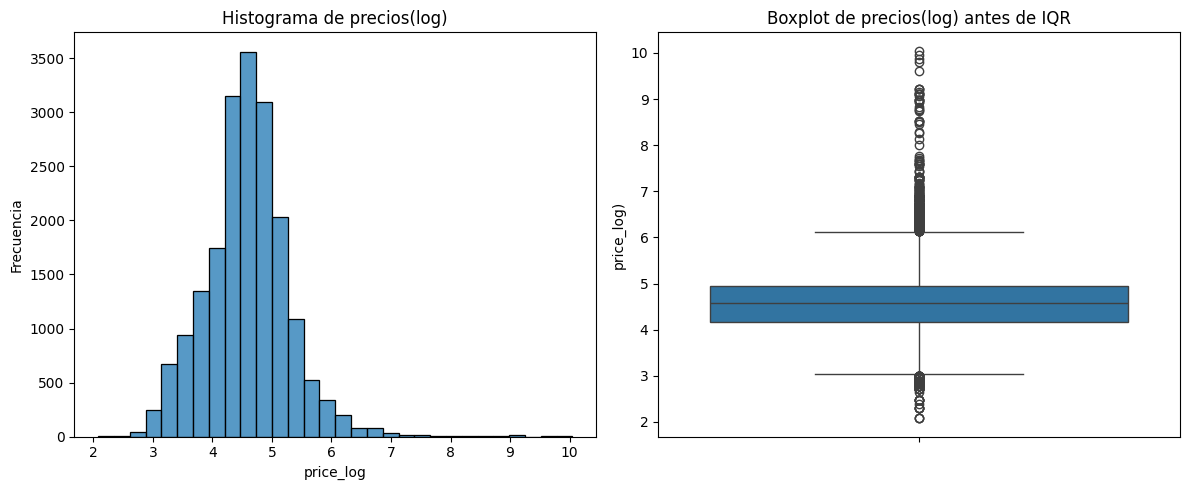

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(listings['price_log'], bins=30, kde=False, ax=axes[0])
axes[0].set_title('Histograma de precios(log)')
axes[0].set_xlabel('price_log')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(y=listings['price_log'], ax=axes[1])
axes[1].set_title('Boxplot de precios(log) antes de IQR')
axes[1].set_ylabel('price_log)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

In [ ]:
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Box(y=listings['price_log'], name='price_log'))
fig.update_layout(title='Price_Log', boxmode='group')
fig.show()

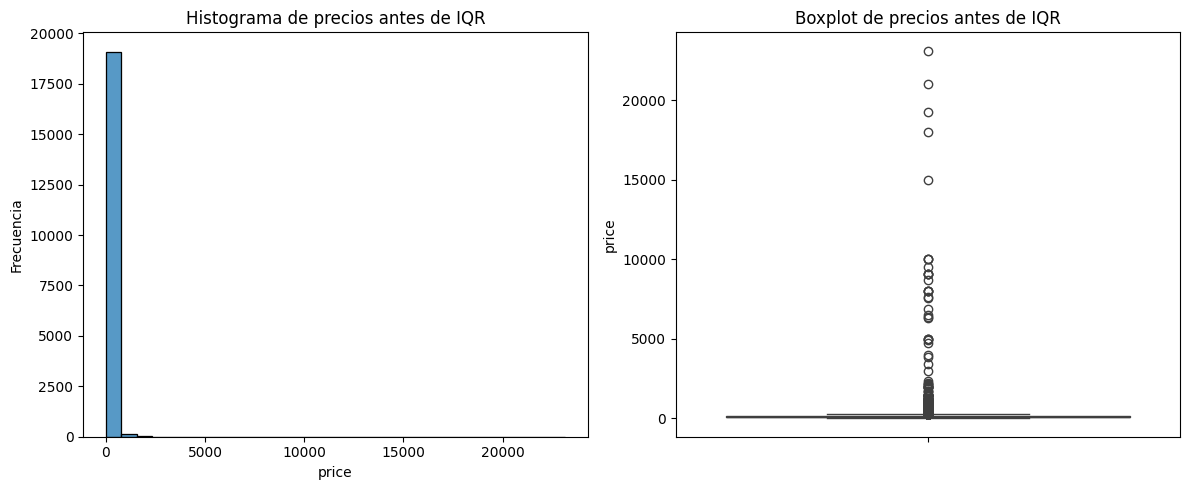

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(listings['price'], bins=30, kde=False, ax=axes[0])
axes[0].set_title('Histograma de precios antes de IQR')
axes[0].set_xlabel('price')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(y=listings['price'], ax=axes[1])
axes[1].set_title('Boxplot de precios antes de IQR')
axes[1].set_ylabel('price')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

In [ ]:
# Los atípicos impactan negativamente en las predicciones del modelo
Q1 = listings['price_log'].quantile(0.25)
Q3 = listings['price_log'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
listings=listings[(listings['price_log'] >= lim_inf) & (listings['price_log'] <= lim_sup)]

In [ ]:
listings.shape

(18703, 68)

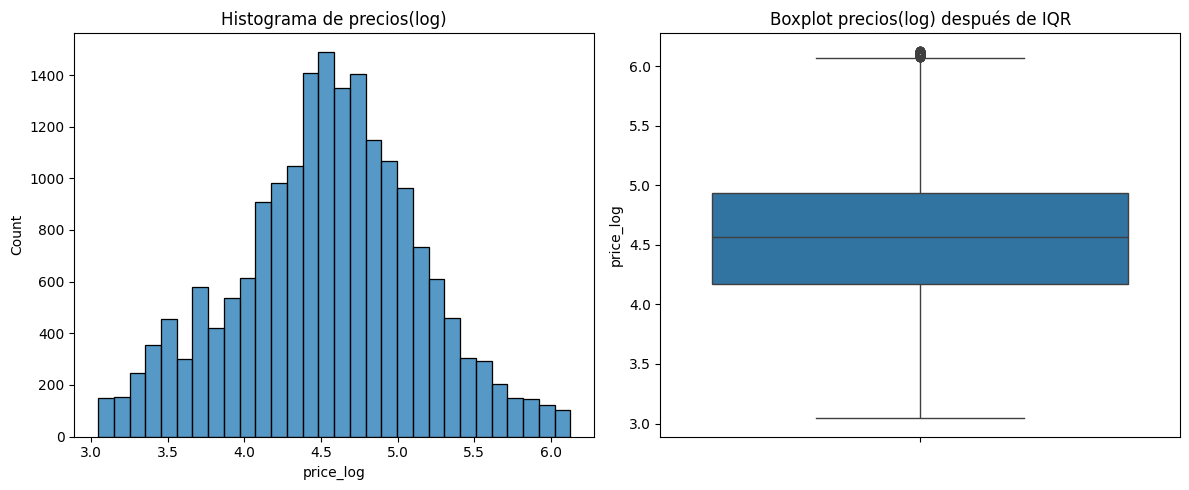

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(listings['price_log'], bins=30, kde=False, ax=axes[0])
axes[0].set_title('Histograma de precios(log)')
sns.boxplot(y=listings['price_log'], ax=axes[1])
axes[1].set_title('Boxplot precios(log) después de IQR')
plt.tight_layout()
plt.show()

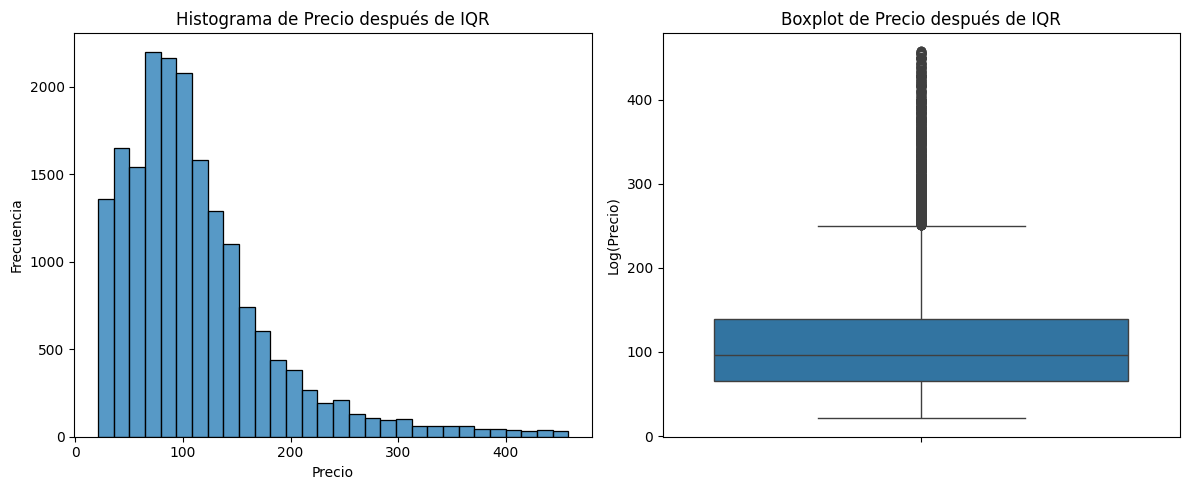

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(listings['price'], bins=30, kde=False, ax=axes[0])
axes[0].set_title('Histograma de Precio después de IQR')
axes[0].set_xlabel('Precio')
axes[0].set_ylabel('Frecuencia')


sns.boxplot(y=listings['price'], ax=axes[1])
axes[1].set_title('Boxplot de Precio después de IQR')
axes[1].set_ylabel('Log(Precio)')
axes[1].set_xlabel('')
plt.tight_layout()
plt.show()

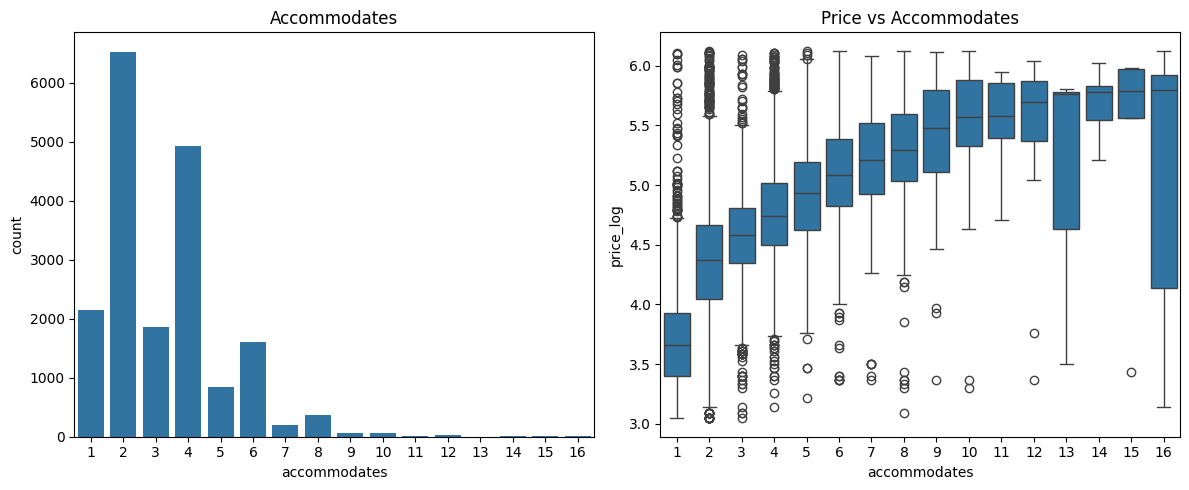

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=listings['accommodates'], data=listings, ax=axes[0])
axes[0].set_title('Accommodates')
sns.boxplot(x='accommodates', y='price_log', data=listings, ax=axes[1])
axes[1].set_title('Price vs Accommodates')
plt.tight_layout()
plt.show()

In [ ]:
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Box(y=listings['accommodates'], name='accommodates'))
fig.update_layout(title='Accommodates', boxmode='group')
fig.show()

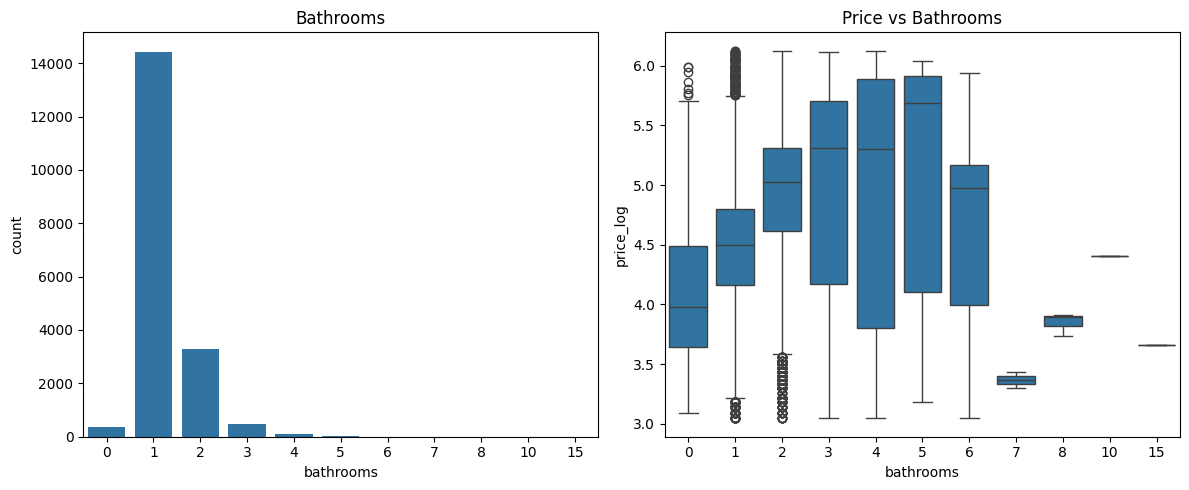

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=listings['bathrooms'], data=listings, ax=axes[0])
axes[0].set_title('Bathrooms')
sns.boxplot(x='bathrooms', y='price_log', data=listings, ax=axes[1])
axes[1].set_title('Price vs Bathrooms')
plt.tight_layout()
plt.show()

In [ ]:
fig = go.Figure()
fig.add_trace(go.Box(y=listings['bathrooms'], name='bathrooms'))
fig.update_layout(title='Bathrooms', boxmode='group')
fig.show()

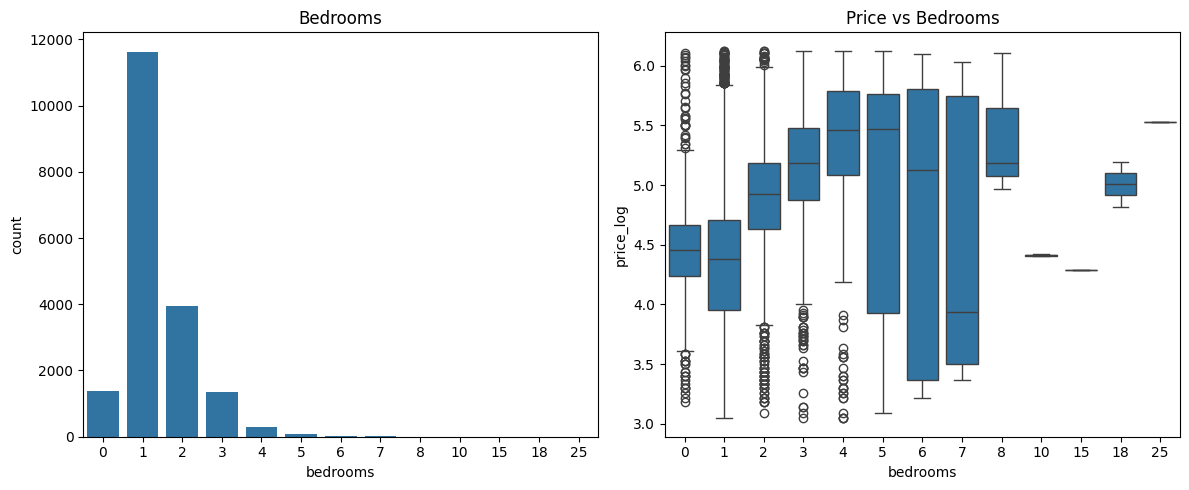

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=listings['bedrooms'], data=listings, ax=axes[0])
axes[0].set_title('Bedrooms')
sns.boxplot(x='bedrooms', y='price_log', data=listings, ax=axes[1])
axes[1].set_title('Price vs Bedrooms')
plt.tight_layout()
plt.show()

In [ ]:
fig = go.Figure()
fig.add_trace(go.Box(y=listings['bedrooms'], name='bedrooms'))
fig.update_layout(title='Bedrooms')
fig.show()

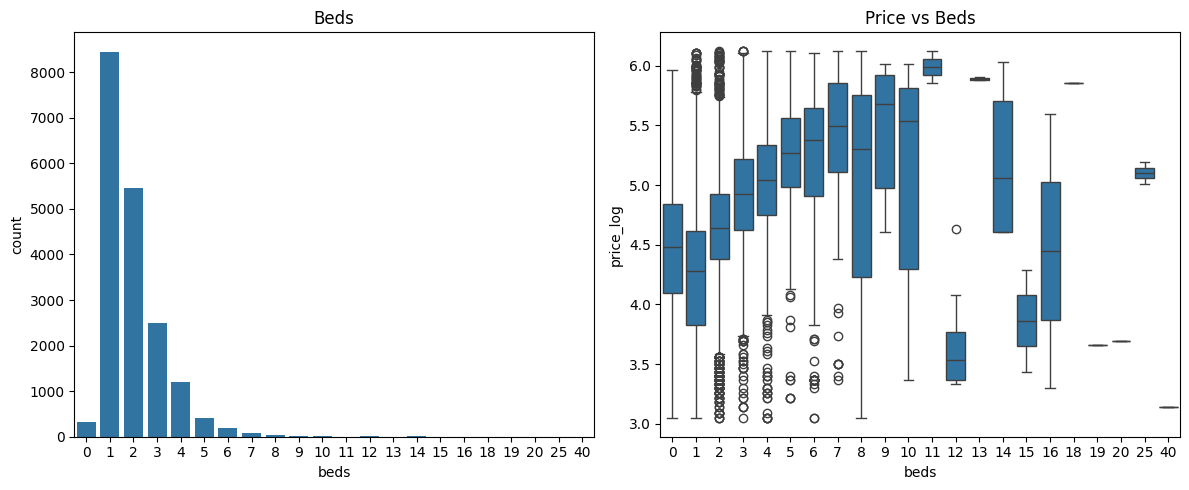

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=listings['beds'], data=listings, ax=axes[0])
axes[0].set_title('Beds')
sns.boxplot(x='beds', y='price_log', data=listings, ax=axes[1])
axes[1].set_title('Price vs Beds')
plt.tight_layout()
plt.show()

In [ ]:
fig = go.Figure()
fig.add_trace(go.Box(y=listings['beds'], name='beds'))
fig.update_layout(title='Beds')
fig.show()

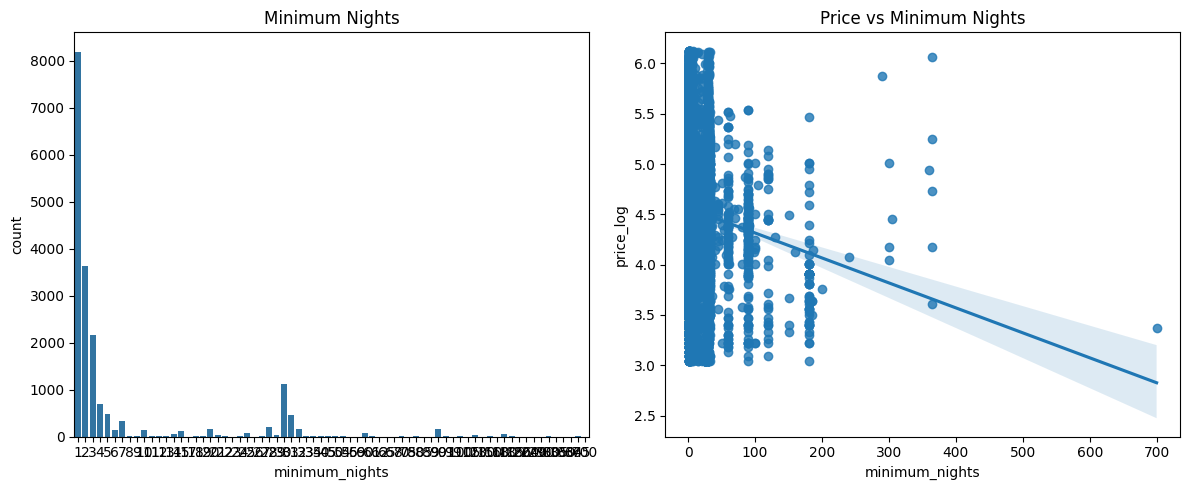

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=listings['minimum_nights'], data=listings, ax=axes[0])
axes[0].set_title('Minimum Nights')
sns.regplot(x='minimum_nights', y='price_log', data=listings, ax=axes[1])
axes[1].set_title('Price vs Minimum Nights')
plt.tight_layout()
plt.show()

In [ ]:
fig = go.Figure()
fig.add_trace(go.Box(y=listings['minimum_nights'], name='minimum_nights'))
fig.update_layout(title='Minimum Nights')
fig.show()

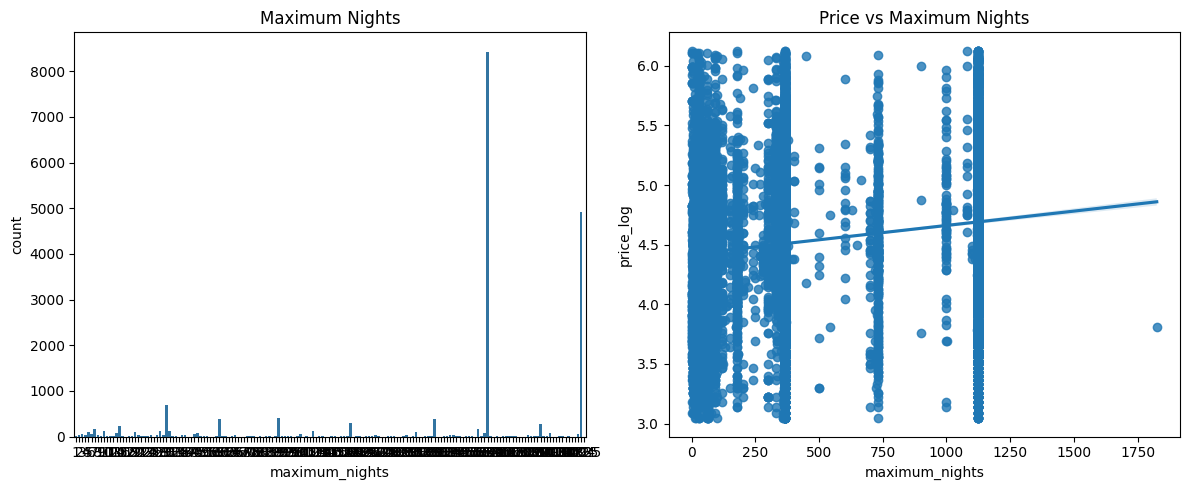

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=listings['maximum_nights'], data=listings, ax=axes[0])
axes[0].set_title('Maximum Nights')
sns.regplot(x='maximum_nights', y='price_log', data=listings, ax=axes[1])
axes[1].set_title('Price vs Maximum Nights')
plt.tight_layout()
plt.show()

In [ ]:
fig = go.Figure()
fig.add_trace(go.Box(y=listings['maximum_nights'], name='maximum_nights'))
fig.update_layout(title='Maximum Nights')
fig.show()

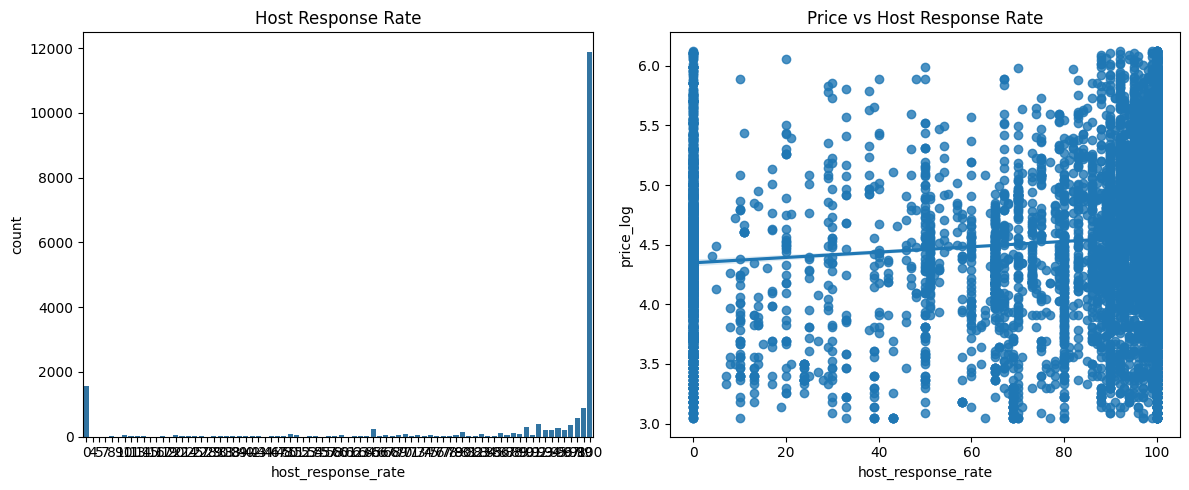

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=listings['host_response_rate'], data=listings, ax=axes[0])
axes[0].set_title('Host Response Rate')
sns.regplot(x='host_response_rate', y='price_log', data=listings, ax=axes[1])
axes[1].set_title('Price vs Host Response Rate')
plt.tight_layout()
plt.show()

In [ ]:
fig = go.Figure()
fig.add_trace(go.Box(y=listings['host_response_rate'], name='host_response_rate'))
fig.update_layout(title='Host Response Rate')
fig.show()

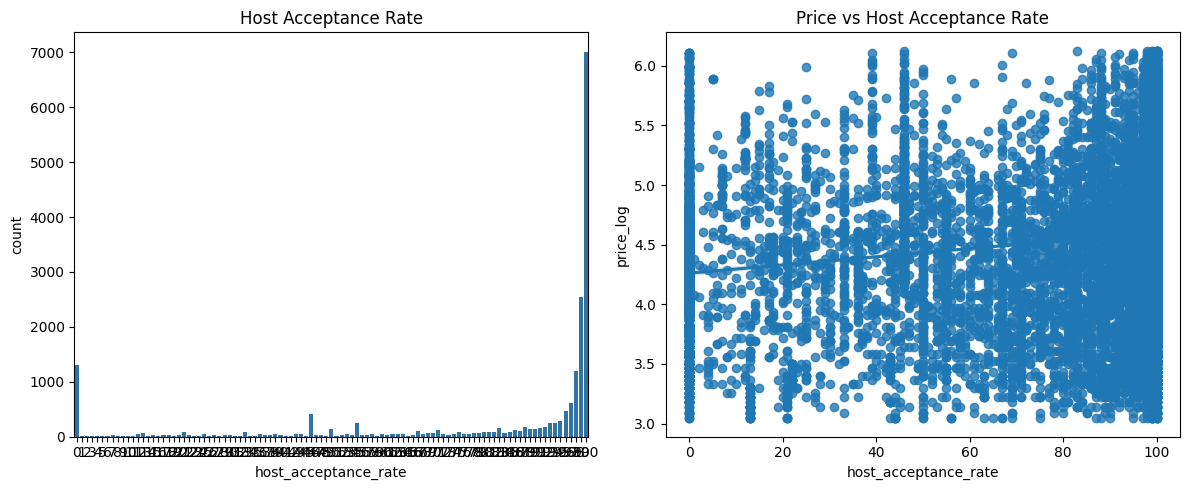

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=listings['host_acceptance_rate'], data=listings, ax=axes[0])
axes[0].set_title('Host Acceptance Rate')
sns.regplot(x='host_acceptance_rate', y='price_log', data=listings, ax=axes[1])
axes[1].set_title('Price vs Host Acceptance Rate')
plt.tight_layout()
plt.show()

In [ ]:
fig = go.Figure()
fig.add_trace(go.Box(y=listings['host_acceptance_rate'], name='host_acceptance_rate'))
fig.update_layout(title='host_acceptance_rate')
fig.show()

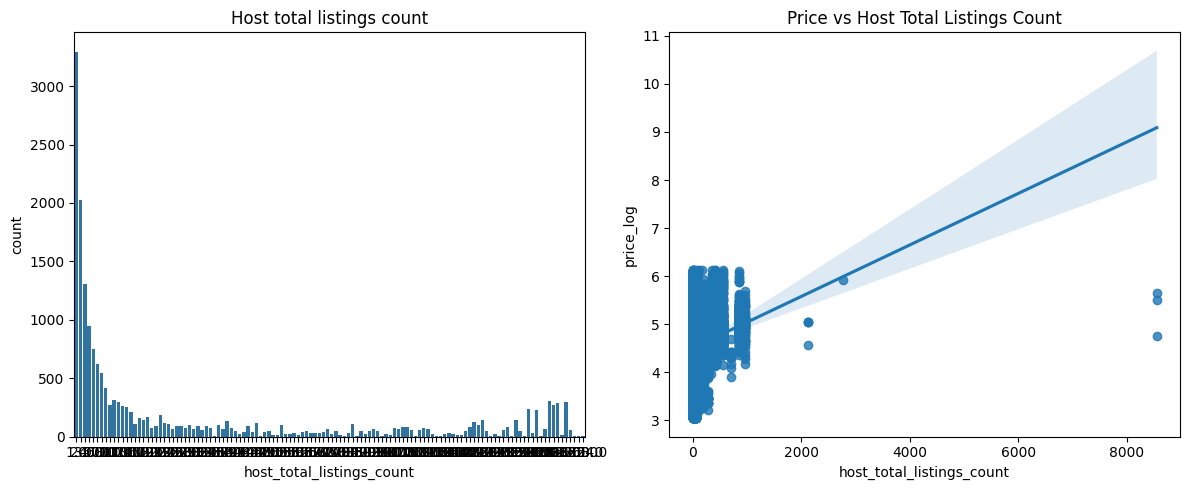

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=listings['host_total_listings_count'], data=listings, ax=axes[0])
axes[0].set_title('Host total listings count')
sns.regplot(x='host_total_listings_count', y='price_log', data=listings, ax=axes[1])
axes[1].set_title('Price vs Host Total Listings Count')
plt.tight_layout()
plt.show()

In [ ]:
fig = go.Figure()
fig.add_trace(go.Box(y=listings['host_total_listings_count'], name='host_total_listings_count'))
fig.update_layout(title='Host Total Listings Count')
fig.show()

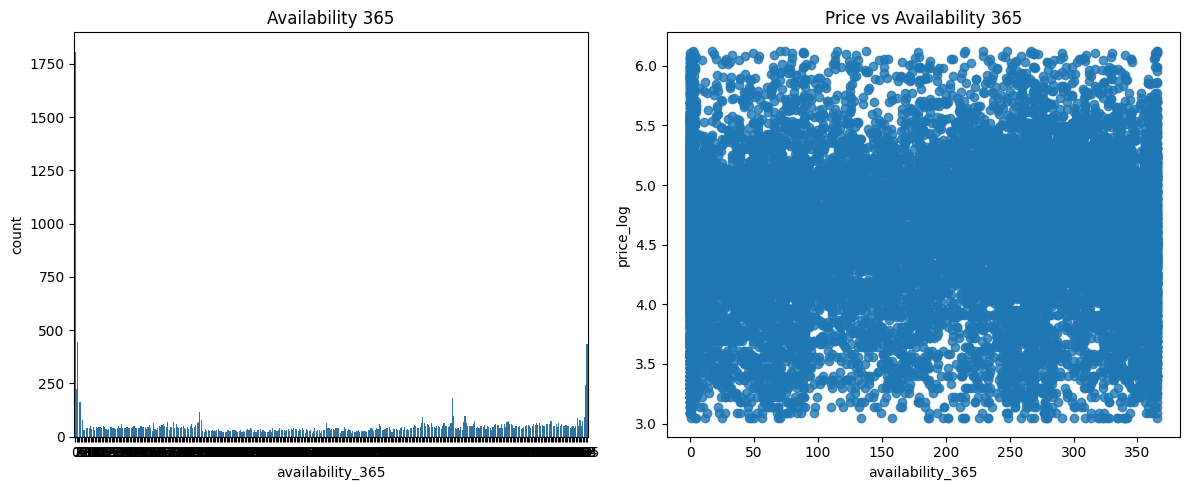

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=listings['availability_365'], data=listings, ax=axes[0])
axes[0].set_title('Availability 365')
sns.regplot(x='availability_365', y='price_log', data=listings, ax=axes[1])
axes[1].set_title('Price vs Availability 365')
plt.tight_layout()
plt.show()

In [ ]:
fig = go.Figure()
fig.add_trace(go.Box(y=listings['availability_365'], name='availability_365'))
fig.update_layout(title='Availability 365')
fig.show()

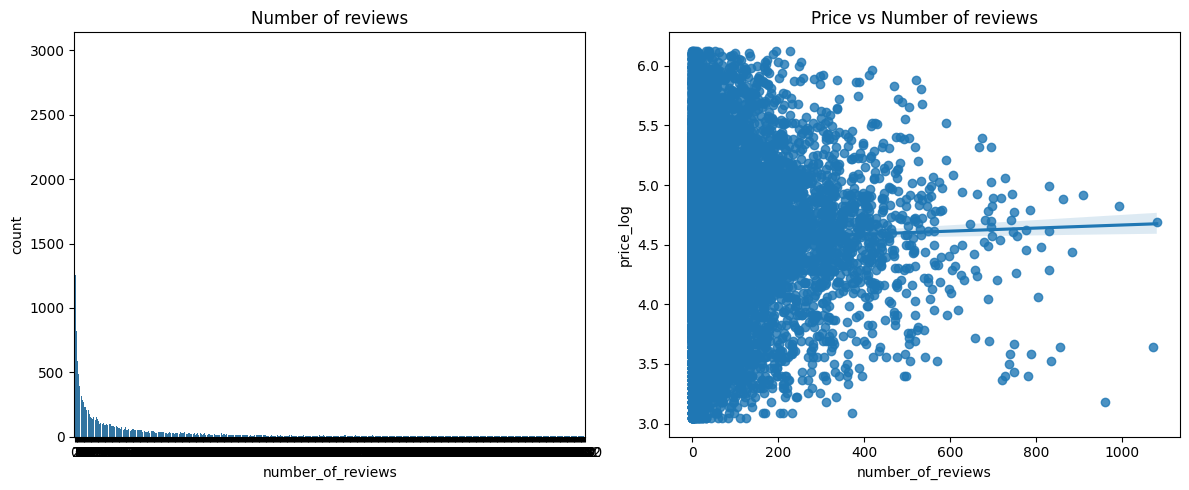

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=listings['number_of_reviews'], data=listings, ax=axes[0])
axes[0].set_title('Number of reviews')
sns.regplot(x='number_of_reviews', y='price_log', data=listings, ax=axes[1])
axes[1].set_title('Price vs Number of reviews')
plt.tight_layout()
plt.show()

In [ ]:
fig = go.Figure()
fig.add_trace(go.Box(y=listings['number_of_reviews'], name='number_of_reviews'))
fig.update_layout(title='Number of reviews')
fig.show()

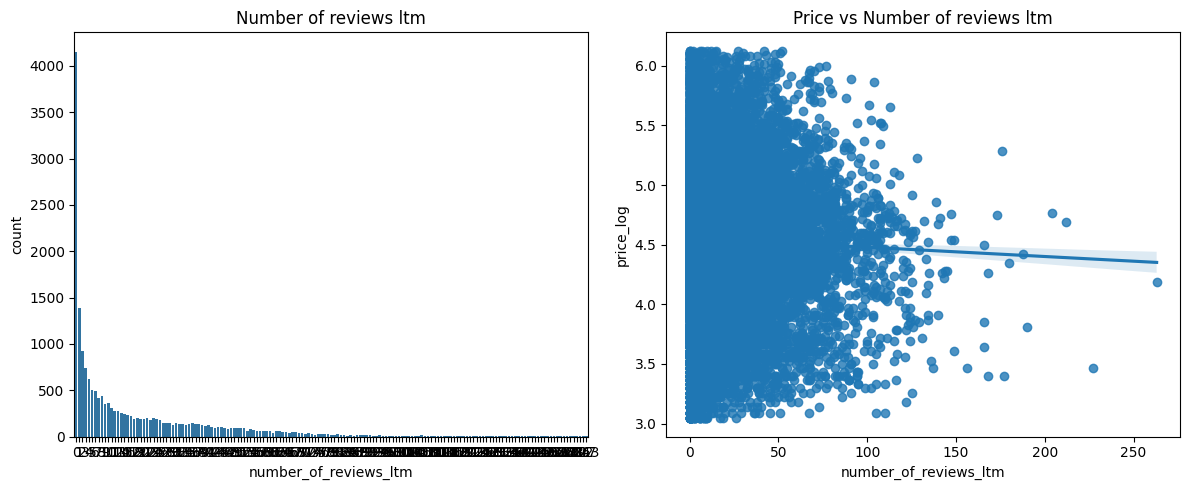

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=listings['number_of_reviews_ltm'], data=listings, ax=axes[0])
axes[0].set_title('Number of reviews ltm')
sns.regplot(x='number_of_reviews_ltm', y='price_log', data=listings, ax=axes[1])
axes[1].set_title('Price vs Number of reviews ltm')
plt.tight_layout()
plt.show()

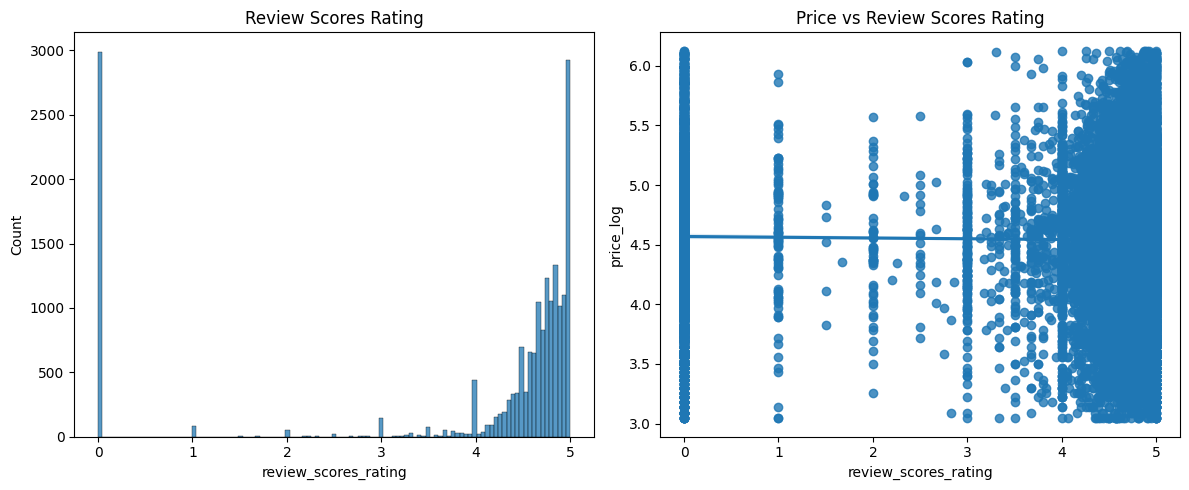

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(x=listings['review_scores_rating'], data=listings, ax=axes[0])
axes[0].set_title('Review Scores Rating')
sns.regplot(x='review_scores_rating', y='price_log', data=listings, ax=axes[1])
axes[1].set_title('Price vs Review Scores Rating')
plt.tight_layout()
plt.show()

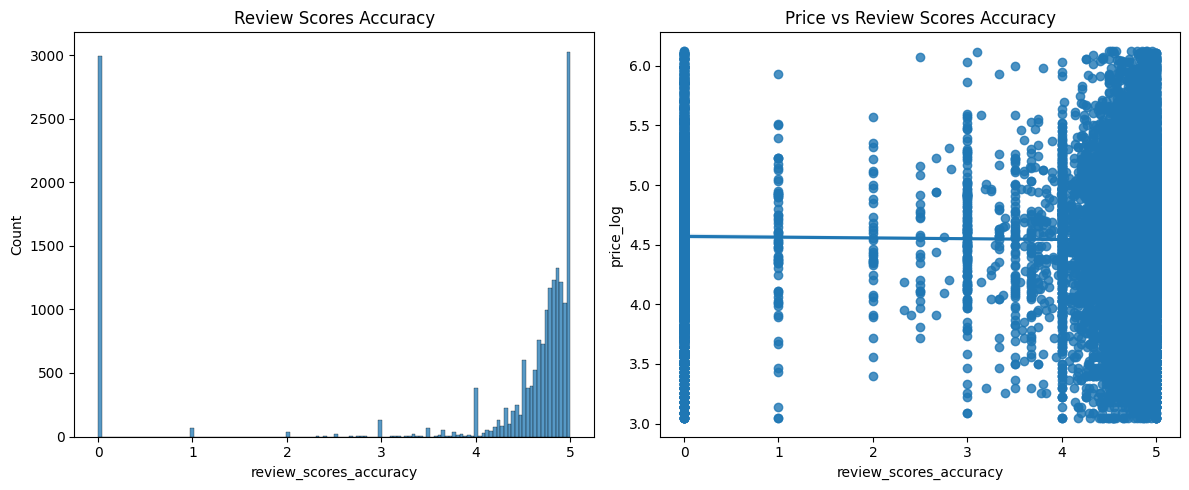

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(x=listings['review_scores_accuracy'], data=listings, ax=axes[0])
axes[0].set_title('Review Scores Accuracy')
sns.regplot(x='review_scores_accuracy', y='price_log', data=listings, ax=axes[1])
axes[1].set_title('Price vs Review Scores Accuracy')
plt.tight_layout()
plt.show()

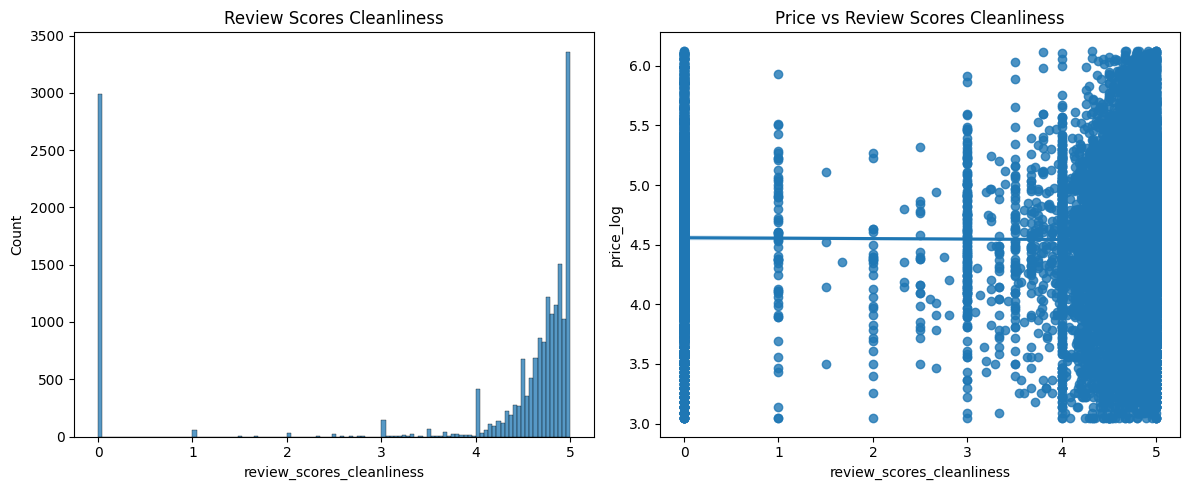

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(x=listings['review_scores_cleanliness'], data=listings, ax=axes[0])
axes[0].set_title('Review Scores Cleanliness')
sns.regplot(x='review_scores_cleanliness', y='price_log', data=listings, ax=axes[1])
axes[1].set_title('Price vs Review Scores Cleanliness')
plt.tight_layout()
plt.show()

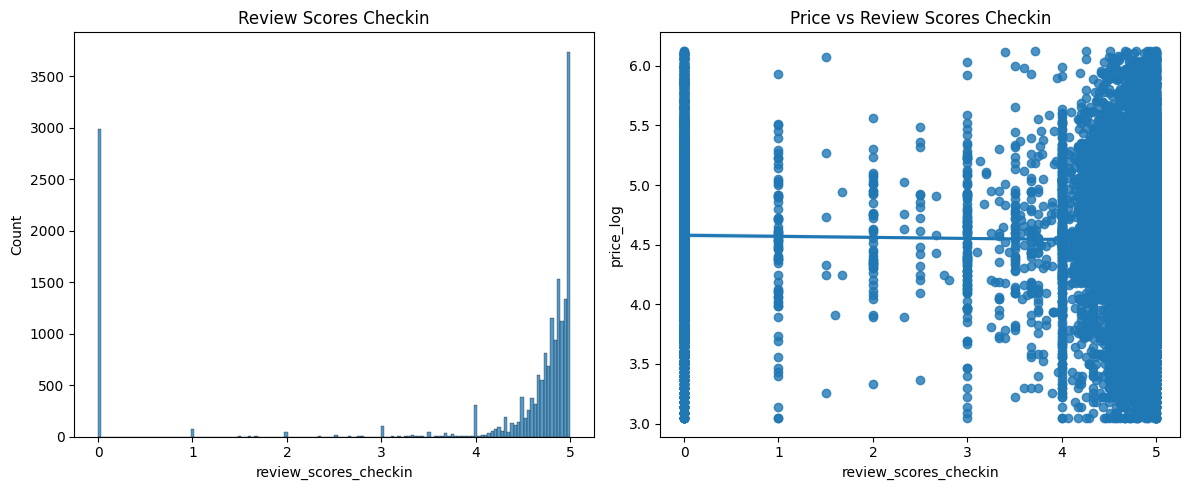

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(x=listings['review_scores_checkin'], data=listings, ax=axes[0])
axes[0].set_title('Review Scores Checkin')
sns.regplot(x='review_scores_checkin', y='price_log', data=listings, ax=axes[1])
axes[1].set_title('Price vs Review Scores Checkin')
plt.tight_layout()
plt.show()

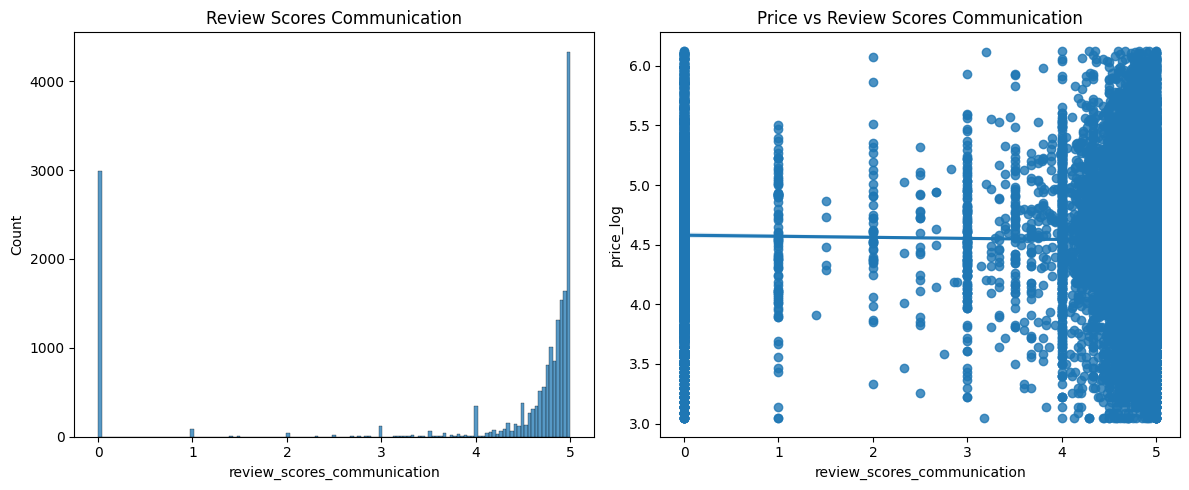

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(x=listings['review_scores_communication'], data=listings, ax=axes[0])
axes[0].set_title('Review Scores Communication')
sns.regplot(x='review_scores_communication', y='price_log', data=listings, ax=axes[1])
axes[1].set_title('Price vs Review Scores Communication')
plt.tight_layout()
plt.show()

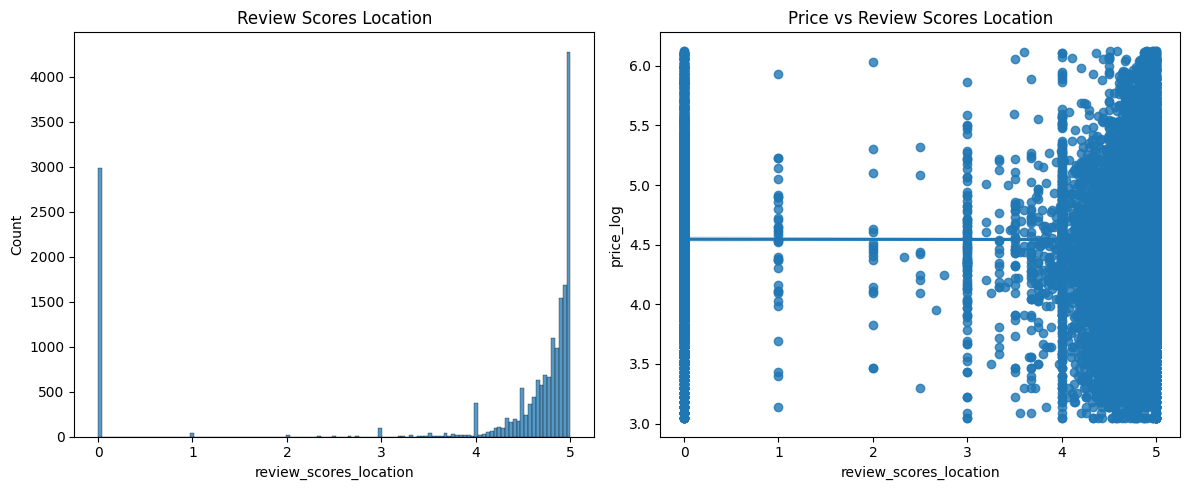

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(x=listings['review_scores_location'], data=listings, ax=axes[0])
axes[0].set_title('Review Scores Location')
sns.regplot(x='review_scores_location', y='price_log', data=listings, ax=axes[1])
axes[1].set_title('Price vs Review Scores Location')
plt.tight_layout()
plt.show()

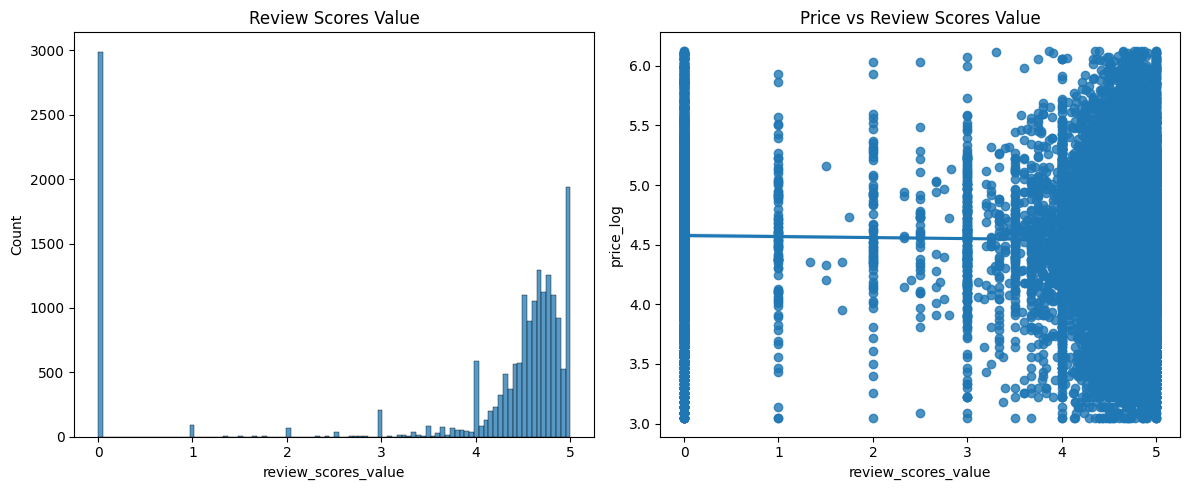

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(x=listings['review_scores_value'], data=listings, ax=axes[0])
axes[0].set_title('Review Scores Value')
sns.regplot(x='review_scores_value', y='price_log', data=listings, ax=axes[1])
axes[1].set_title('Price vs Review Scores Value')
plt.tight_layout()
plt.show()

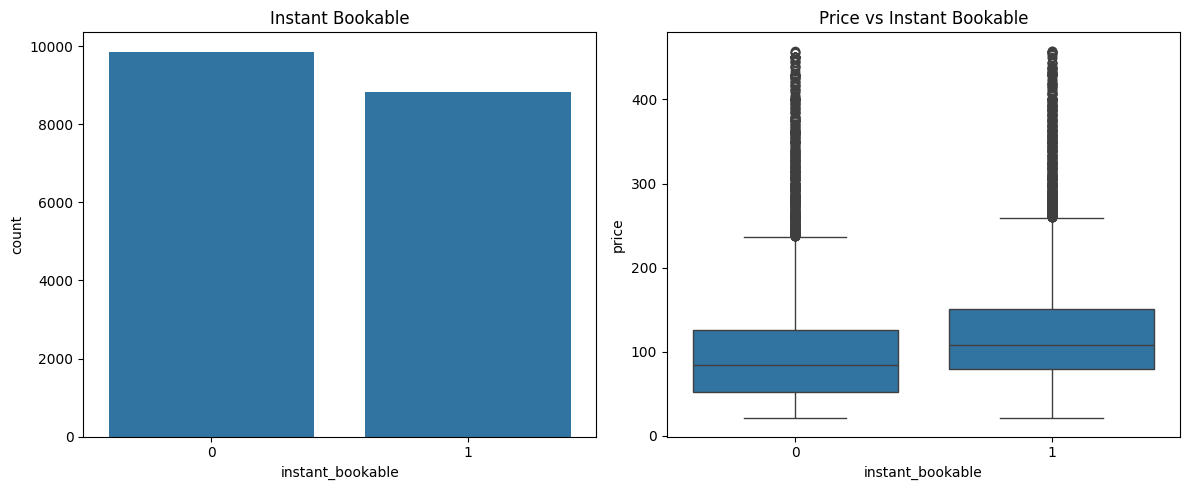

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=listings['instant_bookable'], data=listings, ax=axes[0])
axes[0].set_title('Instant Bookable')
sns.boxplot(x='instant_bookable', y='price', data=listings, ax=axes[1])
axes[1].set_title('Price vs Instant Bookable')
plt.tight_layout()
plt.show()

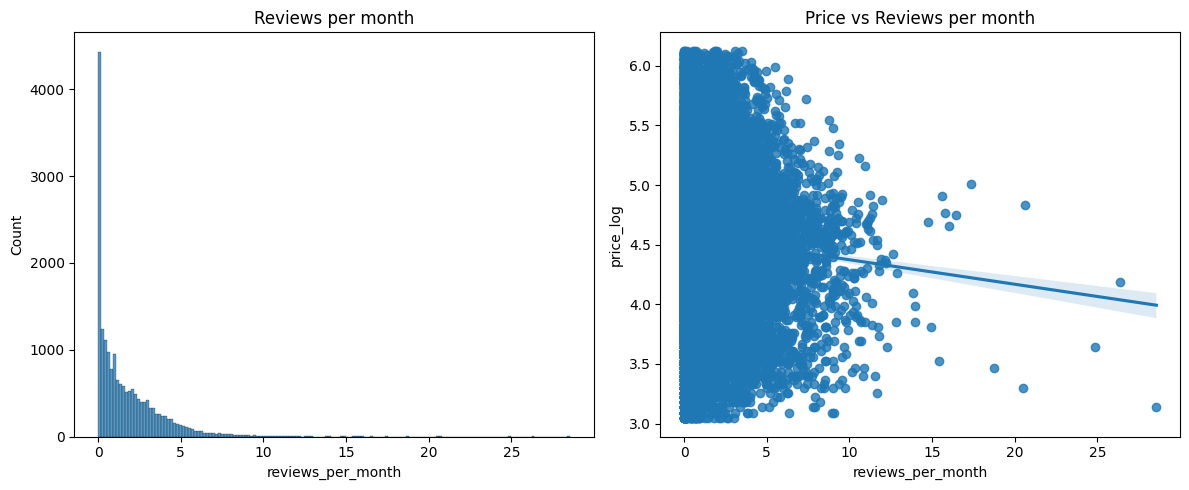

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(x=listings['reviews_per_month'], data=listings, ax=axes[0])
axes[0].set_title('Reviews per month')
sns.regplot(x='reviews_per_month', y='price_log', data=listings, ax=axes[1])
axes[1].set_title('Price vs Reviews per month')
plt.tight_layout()
plt.show()

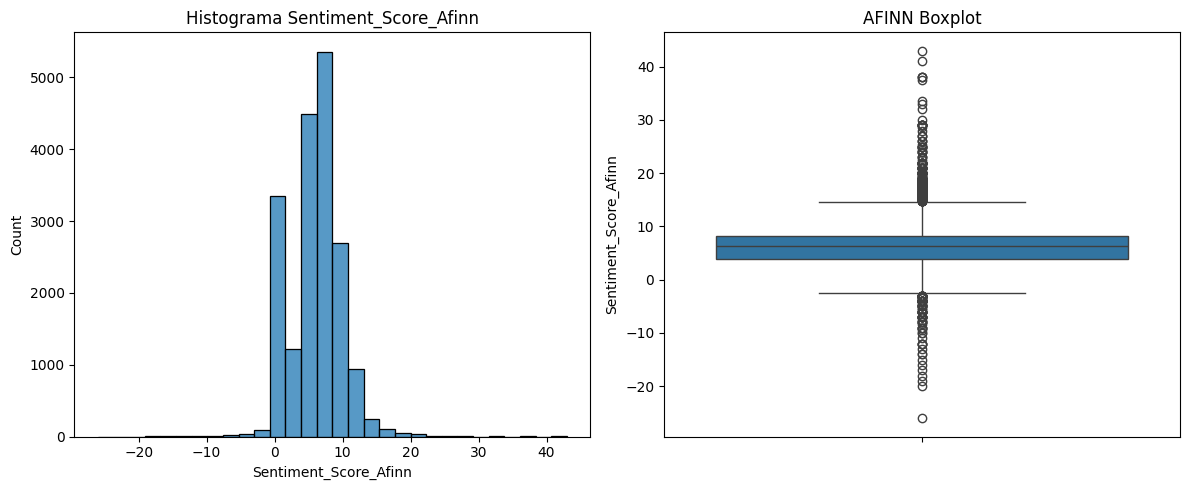

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(listings['Sentiment_Score_Afinn'], bins=30, kde=False, ax=axes[0])
axes[0].set_title('Histograma Sentiment_Score_Afinn')
sns.boxplot(y=listings['Sentiment_Score_Afinn'], ax=axes[1])
axes[1].set_title('AFINN Boxplot')
plt.tight_layout()
plt.show()

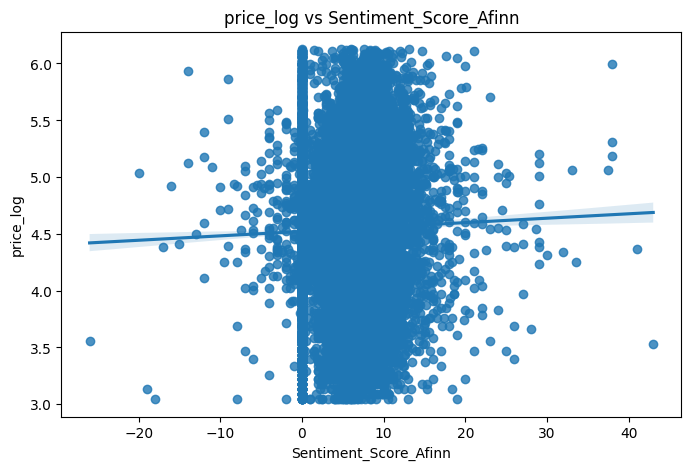

In [ ]:
plt.figure(figsize=(8, 5))
sns.regplot(x='Sentiment_Score_Afinn', y='price_log', data=listings)
plt.xlabel('Sentiment_Score_Afinn')
plt.ylabel('price_log')
plt.title('price_log vs Sentiment_Score_Afinn')
plt.show()

In [ ]:
listings.columns

Index(['id', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost',
       'host_total_listings_count', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'price', 'minimum_nights', 'maximum_nights', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable',
       'reviews_per_month', 'price_log', 'distrito_barajas',
       'distrito_carabanchel', 'distrito_centro', 'distrito_chamartín',
       'distrito_chamberí', 'distrito_ciudad_lineal',
       'distrito_fuencarral___el_pardo', 'distrito_hortaleza',
       'distrito_latina', 'distrito_moncloa___aravaca', 'distrito_moratalaz',
       'distrito_puente_de_vallecas', 'distrito_retiro', 'distrito_salamanca',
       'distrito_san_blas___canillejas', 'distrit

In [ ]:
var_host=['price_log','host_response_time', 'host_response_rate',
       'host_acceptance_rate','host_total_listings_count','host_is_superhost','instant_bookable']
var_apt=['price_log','accommodates', 'bathrooms', 'bedrooms', 'beds','minimum_nights',
       'maximum_nights', 'availability_365','rt_hotel_room', 'rt_private_room',
       'rt_shared_room', 'self_check_in', 'air_conditioning',
       'high_end_electronics', 'bbq', 'kitchen_and_else', 'bed_linen',
       'breakfast', 'tv', 'wifi', 'white_goods', 'elevator', 'gym', 'parking',
       'outdoor_space', 'hot_tub_sauna_or_pool', 'long_term_stays',
       'pets_allowed', 'security','instant_bookable']
var_reviews=['price_log','number_of_reviews', 'reviews_per_month',
       'number_of_reviews_ltm', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'Sentiment_Score_Afinn']
var_loc=['price_log', 'distrito_barajas',
       'distrito_carabanchel', 'distrito_centro', 'distrito_chamartín',
       'distrito_chamberí', 'distrito_ciudad_lineal',
       'distrito_fuencarral___el_pardo', 'distrito_hortaleza',
       'distrito_latina', 'distrito_moncloa___aravaca', 'distrito_moratalaz',
       'distrito_puente_de_vallecas', 'distrito_retiro', 'distrito_salamanca',
       'distrito_san_blas___canillejas', 'distrito_tetuán', 'distrito_usera',
       'distrito_vicálvaro', 'distrito_villa_de_vallecas',
       'distrito_villaverde']

In [ ]:
# Correlación Pearson variables host
corr_matrix = listings[var_host].corr()
text = np.round(corr_matrix.values, 2).astype(str)
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu',
    zmin=-1,
    zmax=1,
    text=text,
    texttemplate="%{text}",
    colorbar=dict(title="Correlación")))
fig.update_layout(
    title="Matriz de Correlación",
    xaxis_title="",
    yaxis_title="",
    xaxis_showgrid=False,
    yaxis_showgrid=False,
    width=800,
    height=800)
fig.show()

In [ ]:
# Correlación Kendall variables host
corr_matrix = listings[var_host].corr(method='kendall')
text = np.round(corr_matrix.values, 2).astype(str)
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu',
    zmin=-1,
    zmax=1,
    text=text,
    texttemplate="%{text}",
    colorbar=dict(title="Correlación")))
fig.update_layout(
    title="Matriz de Correlación",
    xaxis_title="",
    yaxis_title="",
    xaxis_showgrid=False,
    yaxis_showgrid=False,
    width=800,
    height=800)
fig.show()

In [ ]:
# Correlación Spearman variables host
corr_matrix = listings[var_host].corr(method='spearman')
text = np.round(corr_matrix.values, 2).astype(str)
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu',
    zmin=-1,
    zmax=1,
    text=text,
    texttemplate="%{text}",
    colorbar=dict(title="Correlación")))
fig.update_layout(
    title="Matriz de Correlación",
    xaxis_title="",
    yaxis_title="",
    xaxis_showgrid=False,
    yaxis_showgrid=False,
    width=800,   # ancho en píxeles
    height=800   # alto en píxeles
)
fig.show()

In [ ]:
#Correlación Pearson variables apartamento
corr_matrix = listings[var_apt].corr()
text = np.round(corr_matrix.values, 2).astype(str)
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu',
    zmin=-1,
    zmax=1,
    text=text,
    texttemplate="%{text}",
    colorbar=dict(title="Correlación")))
fig.update_layout(
    title="Matriz de Correlación",
    xaxis_title="",
    yaxis_title="",
    xaxis_showgrid=False,
    yaxis_showgrid=False,
    width=900,
    height=800)
fig.show()

In [ ]:
#Correlación Kendall variables apartamento
corr_matrix = listings[var_apt].corr(method='kendall')
text = np.round(corr_matrix.values, 2).astype(str)
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu',
    zmin=-1,
    zmax=1,
    text=text,
    texttemplate="%{text}",
    colorbar=dict(title="Correlación")))
fig.update_layout(
    title="Matriz de Correlación",
    xaxis_title="",
    yaxis_title="",
    xaxis_showgrid=False,
    yaxis_showgrid=False,
    width=900,
    height=800)
fig.show()

In [ ]:
#Correlación Spearman variables apartamento
corr_matrix = listings[var_apt].corr(method='spearman')
text = np.round(corr_matrix.values, 2).astype(str)
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu',
    zmin=-1,
    zmax=1,
    text=text,
    texttemplate="%{text}",
    colorbar=dict(title="Correlación")))
fig.update_layout(
    title="Matriz de Correlación",
    xaxis_title="",
    yaxis_title="",
    xaxis_showgrid=False,
    yaxis_showgrid=False,
    width=900,
    height=800)
fig.show()

In [ ]:
# Correlación Pearson variables reseñas
corr_matrix = listings[var_reviews].corr()
text = np.round(corr_matrix.values, 2).astype(str)
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu',
    texttemplate="%{text}",
    zmin=-1,
    zmax=1,
    text=text,

    colorbar=dict(title="Correlación")))
fig.update_layout(
    title="Matriz de Correlación",
    xaxis_title="",
    yaxis_title="",
    xaxis_showgrid=False,
    yaxis_showgrid=False,
    width=900,
    height=800)
fig.show()

In [ ]:
# Correlación Kendall variables reseñas
corr_matrix = listings[var_reviews].corr(method='kendall')
text = np.round(corr_matrix.values, 2).astype(str)
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu',
    texttemplate="%{text}",
    zmin=-1,
    zmax=1,
    text=text,

    colorbar=dict(title="Correlación")))
fig.update_layout(
    title="Matriz de Correlación",
    xaxis_title="",
    yaxis_title="",
    xaxis_showgrid=False,
    yaxis_showgrid=False,
    width=900,
    height=800)
fig.show()

In [ ]:
# Correlación Spearman variables reseñas
corr_matrix = listings[var_reviews].corr(method='spearman')
text = np.round(corr_matrix.values, 2).astype(str)
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu',
    texttemplate="%{text}",
    zmin=-1,
    zmax=1,
    text=text,

    colorbar=dict(title="Correlación")))
fig.update_layout(
    title="Matriz de Correlación",
    xaxis_title="",
    yaxis_title="",
    xaxis_showgrid=False,
    yaxis_showgrid=False,
    width=900,
    height=800)
fig.show()

In [ ]:
# Correlación Pearson variables localización
corr_matrix = listings[var_loc].corr()
text = np.round(corr_matrix.values, 2).astype(str)
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu',
    texttemplate="%{text}",
    zmin=-1,
    zmax=1,
    text=text,

    colorbar=dict(title="Correlación")))
fig.update_layout(
    title="Matriz de Correlación",
    xaxis_title="",
    yaxis_title="",
    xaxis_showgrid=False,
    yaxis_showgrid=False,
    width=900,
    height=800)
fig.show()

In [ ]:
# Correlación Kendall variables localización
corr_matrix = listings[var_loc].corr(method='kendall')
text = np.round(corr_matrix.values, 2).astype(str)
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu',
    texttemplate="%{text}",
    zmin=-1,
    zmax=1,
    text=text,

    colorbar=dict(title="Correlación")))
fig.update_layout(
    title="Matriz de Correlación",
    xaxis_title="",
    yaxis_title="",
    xaxis_showgrid=False,
    yaxis_showgrid=False,
    width=900,
    height=800)
fig.show()

In [ ]:
# Correlación Spearman variables localización
corr_matrix = listings[var_loc].corr(method='spearman')
text = np.round(corr_matrix.values, 2).astype(str)
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu',
    texttemplate="%{text}",
    zmin=-1,
    zmax=1,
    text=text,

    colorbar=dict(title="Correlación")))
fig.update_layout(
    title="Matriz de Correlación",
    xaxis_title="",
    yaxis_title="",
    xaxis_showgrid=False,
    yaxis_showgrid=False,
    width=900,
    height=800)
fig.show()

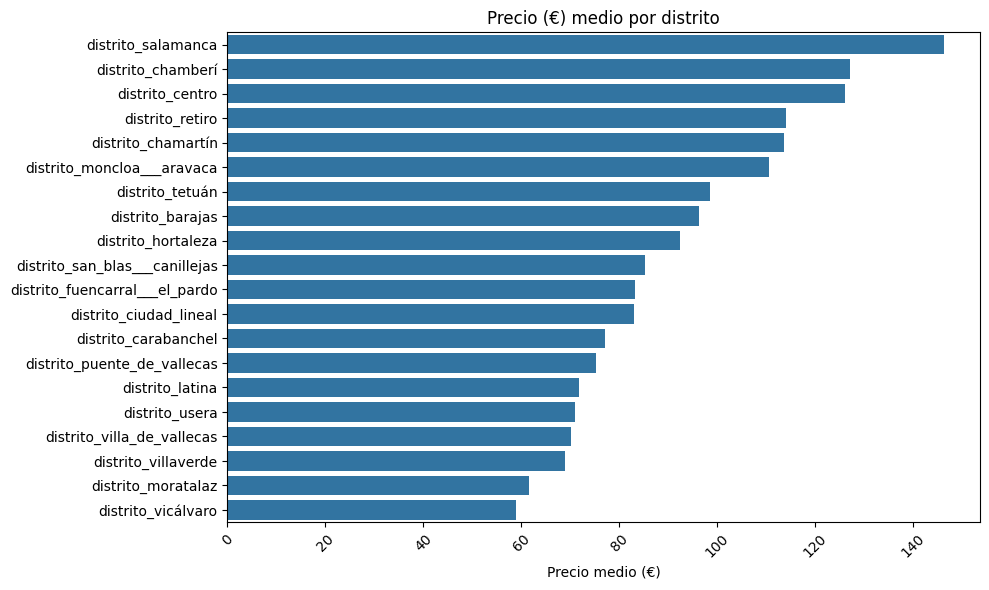

In [ ]:
df=listings.copy()
district_cols = [col for col in df.columns if col.startswith('distrito_')]
df['distrito'] = listings[district_cols].idxmax(axis=1).str.replace('distrito_', 'distrito_')
df_distrito = df.groupby('distrito')['price'].mean().reset_index()
df_distrito = df_distrito.sort_values(by='price', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=df_distrito, y='distrito', x='price')
plt.xticks(rotation=45)
plt.title('Precio (€) medio por distrito')
plt.xlabel('Precio medio (€)')
plt.ylabel('')
plt.tight_layout()
plt.show()


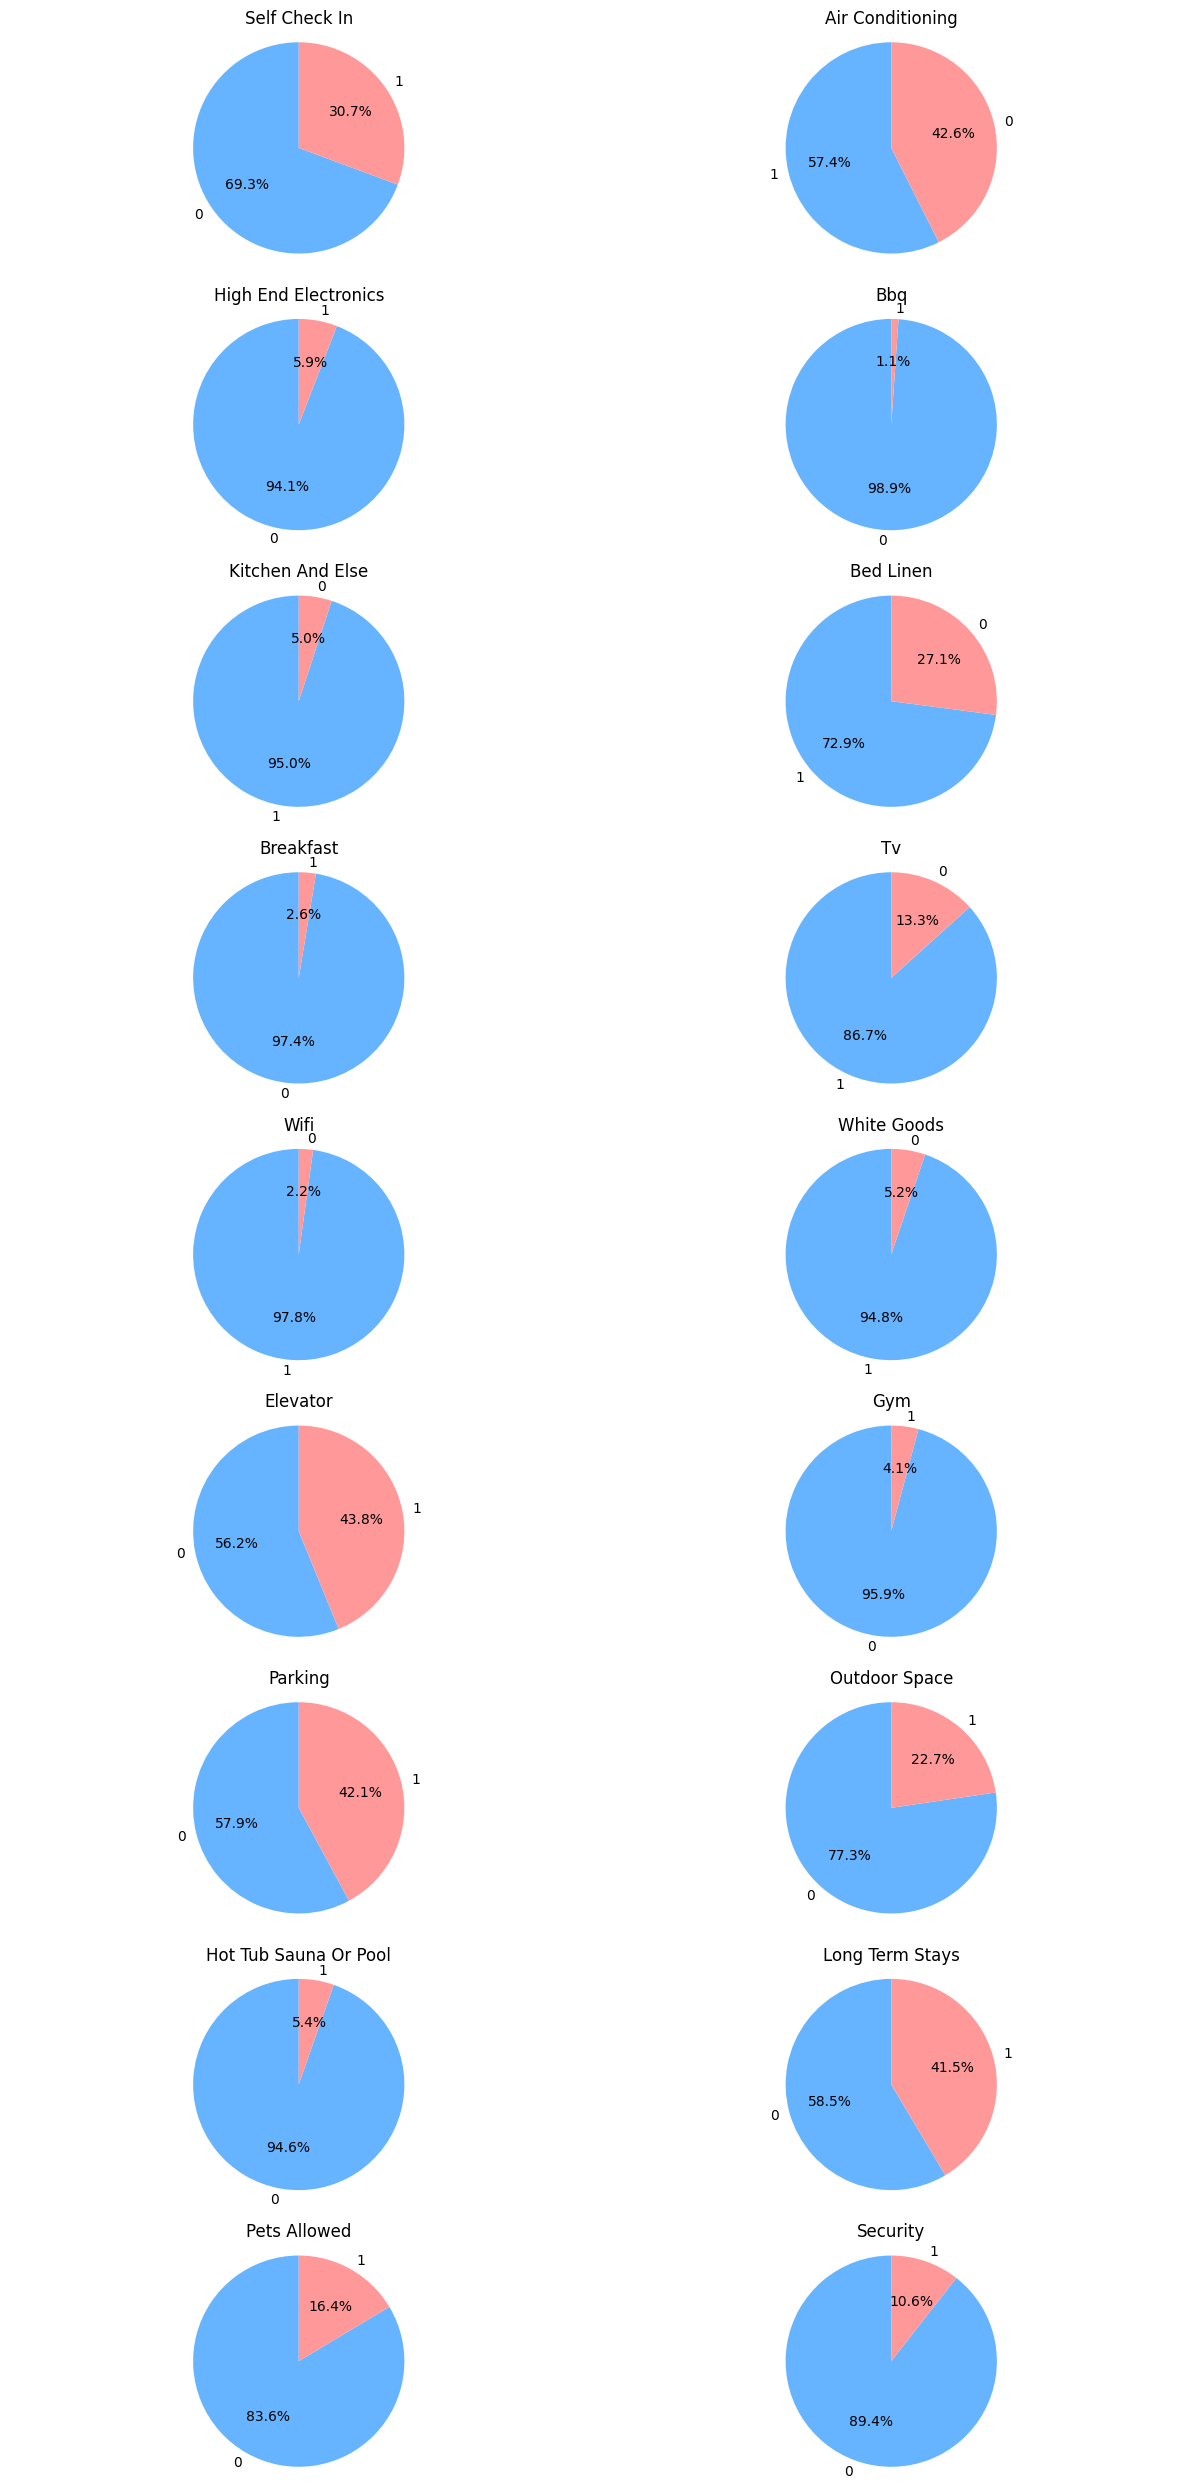

In [ ]:
fig, axes = plt.subplots(9, 2, figsize=(12, 25))
axes = axes.flatten()

columnas = [
    'self_check_in', 'air_conditioning', 'high_end_electronics', 'bbq', 'kitchen_and_else',
    'bed_linen', 'breakfast', 'tv', 'wifi', 'white_goods', 'elevator', 'gym', 'parking',
    'outdoor_space', 'hot_tub_sauna_or_pool', 'long_term_stays', 'pets_allowed', 'security'
]
for i, col in enumerate(columnas):
    valores = listings[col].value_counts(dropna=False)
    labels = valores.index.astype(str)
    sizes = valores.values

    axes[i].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=["#66b3ff", "#ff9999"])
    axes[i].axis('equal')
    axes[i].set_title(col.replace("_", " ").title())

plt.tight_layout()
plt.show()

In [ ]:
# Variables con valor 1 bajo trasnformadas en una sola que representa la unión de las commodities
listings['commo']= ((listings['self_check_in'] == 1) | (listings['high_end_electronics'] == 1)
 | (listings['bbq'] ==1 ) | (listings['breakfast'] == 1)| (listings['gym'] == 1) | (listings['outdoor_space'] ==1)
 | (listings['hot_tub_sauna_or_pool'] == 1) | (listings['pets_allowed'] == 1)
 | (listings['security'] == 1)).astype(int)


listings=listings.drop(columns=['self_check_in','high_end_electronics', 'bbq', 'bed_linen',
        'breakfast','gym', 'parking',
        'outdoor_space', 'hot_tub_sauna_or_pool',
        'pets_allowed', 'security'])

In [ ]:
# Correlación Pearson variables apartamentos con 'commo'
var_apt=['price_log','accommodates', 'bathrooms', 'bedrooms', 'beds','minimum_nights',
       'maximum_nights', 'availability_365','rt_hotel_room', 'rt_private_room',
       'rt_shared_room', 'air_conditioning',
       'kitchen_and_else', 'tv', 'wifi', 'white_goods', 'elevator',
       'long_term_stays',
       'commo','instant_bookable']
corr_matrix = listings[var_apt].corr()
text = np.round(corr_matrix.values, 2).astype(str)
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu',
    zmin=-1,
    zmax=1,
    text=text,
    texttemplate="%{text}",
    colorbar=dict(title="Correlación")))
fig.update_layout(
    title="Matriz de Correlación de características del apartamento",
    xaxis_title="",
    yaxis_title="",
    xaxis_showgrid=False,
    yaxis_showgrid=False,
    width=900,
    height=800)
fig.show()

In [ ]:
# Correlación Kendall variables apartamentos con 'commo'
var_apt=['price_log','accommodates', 'bathrooms', 'bedrooms', 'beds','minimum_nights',
       'maximum_nights', 'availability_365','rt_hotel_room', 'rt_private_room',
       'rt_shared_room', 'air_conditioning',
       'kitchen_and_else', 'tv', 'wifi', 'white_goods', 'elevator',
       'long_term_stays',
       'commo','instant_bookable']
corr_matrix = listings[var_apt].corr(method='kendall')
text = np.round(corr_matrix.values, 2).astype(str)
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu',
    zmin=-1,
    zmax=1,
    text=text,
    texttemplate="%{text}",
    colorbar=dict(title="Correlación")))
fig.update_layout(
    title="Matriz de Correlación de características del apartamento",
    xaxis_title="",
    yaxis_title="",
    xaxis_showgrid=False,
    yaxis_showgrid=False,
    width=900,
    height=800)
fig.show()

In [ ]:
# Correlación Spearman variables apartamentos con 'commo'
var_apt=['price_log','accommodates', 'bathrooms', 'bedrooms', 'beds','minimum_nights',
       'maximum_nights', 'availability_365','rt_hotel_room', 'rt_private_room',
       'rt_shared_room', 'air_conditioning',
       'kitchen_and_else', 'tv', 'wifi', 'white_goods', 'elevator',
       'long_term_stays',
       'commo','instant_bookable']
corr_matrix = listings[var_apt].corr(method='spearman')
text = np.round(corr_matrix.values, 2).astype(str)
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu',
    zmin=-1,
    zmax=1,
    text=text,
    texttemplate="%{text}",
    colorbar=dict(title="Correlación")))
fig.update_layout(
    title="Matriz de Correlación de características del apartamento",
    xaxis_title="",
    yaxis_title="",
    xaxis_showgrid=False,
    yaxis_showgrid=False,
    width=900,
    height=800)
fig.show()

In [ ]:
listings.columns

Index(['id', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost',
       'host_total_listings_count', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'price', 'minimum_nights', 'maximum_nights', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable',
       'reviews_per_month', 'price_log', 'distrito_barajas',
       'distrito_carabanchel', 'distrito_centro', 'distrito_chamartín',
       'distrito_chamberí', 'distrito_ciudad_lineal',
       'distrito_fuencarral___el_pardo', 'distrito_hortaleza',
       'distrito_latina', 'distrito_moncloa___aravaca', 'distrito_moratalaz',
       'distrito_puente_de_vallecas', 'distrito_retiro', 'distrito_salamanca',
       'distrito_san_blas___canillejas', 'distrit

In [ ]:
# VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = listings.drop(columns=['price_log','price','id','review_scores_rating'])
X = add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print(vif_data)

                          Variable         VIF
0                            const  120.303566
1           review_scores_accuracy   77.423825
2              review_scores_value   59.482131
3      review_scores_communication   59.435689
4            review_scores_checkin   53.996098
5        review_scores_cleanliness   47.056116
6           review_scores_location   40.061815
7                  distrito_centro    5.327216
8            number_of_reviews_ltm    4.989172
9                reviews_per_month    3.946210
10                    accommodates    3.351048
11                            beds    2.857704
12            host_acceptance_rate    2.671327
13           Sentiment_Score_Afinn    2.433554
14               number_of_reviews    2.165594
15              distrito_salamanca    2.153757
16                 distrito_tetuán    2.140033
17               distrito_chamberí    2.114485
18              host_response_rate    2.096488
19                        bedrooms    2.076925
20           

In [ ]:
listings.columns

Index(['id', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost',
       'host_total_listings_count', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'price', 'minimum_nights', 'maximum_nights', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable',
       'reviews_per_month', 'price_log', 'distrito_barajas',
       'distrito_carabanchel', 'distrito_centro', 'distrito_chamartín',
       'distrito_chamberí', 'distrito_ciudad_lineal',
       'distrito_fuencarral___el_pardo', 'distrito_hortaleza',
       'distrito_latina', 'distrito_moncloa___aravaca', 'distrito_moratalaz',
       'distrito_puente_de_vallecas', 'distrito_retiro', 'distrito_salamanca',
       'distrito_san_blas___canillejas', 'distrit

In [ ]:
listings.shape

(18703, 58)

In [ ]:
listings[['host_response_time','host_response_rate',
       'host_acceptance_rate','host_total_listings_count', 'accommodates', 'bathrooms', 'bedrooms',
       'beds','minimum_nights', 'maximum_nights', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value','reviews_per_month', 'price_log','Sentiment_Score_Afinn'
          ]].describe()

,host_response_time,host_response_rate,host_acceptance_rate,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_365,number_of_reviews,number_of_reviews_ltm,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,price_log,Sentiment_Score_Afinn
count,18703.000000,18703.000000,18703.000000,18703.000000,18703.000000,18703.000000,18703.000000,18703.000000,18703.000000,18703.000000,18703.000000,18703.000000,18703.000000,18703.000000,18703.000000,18703.000000,18703.000000,18703.000000,18703.000000,18703.000000,18703.000000,18703.000000,18703.000000
mean,1.330803,87.357910,82.396033,73.011121,3.257018,1.230819,1.361814,1.946051,7.693365,511.982570,173.231407,56.410736,17.848313,3.902392,3.945980,3.936921,3.981060,3.987885,3.986922,3.818332,1.722241,4.543808,5.884191
std,0.857145,29.215272,30.439506,194.240065,1.825764,0.582172,0.901306,1.366498,19.626900,396.675714,126.418803,96.768996,23.474839,1.756324,1.766449,1.762280,1.781159,1.789102,1.771934,1.727408,1.967111,0.601708,3.983707
min,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.044522,-26.000000
25%,1.000000,95.000000,82.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,360.000000,49.000000,2.000000,1.000000,4.280000,4.380000,4.330000,4.470000,4.460000,4.410000,4.110000,0.220000,4.174387,3.828125
50%,1.000000,100.000000,99.000000,7.000000,3.000000,1.000000,1.000000,2.000000,2.000000,365.000000,180.000000,16.000000,8.000000,4.690000,4.750000,4.730000,4.800000,4.830000,4.800000,4.590000,1.050000,4.564348,6.250000
75%,1.000000,100.000000,100.000000,43.000000,4.000000,1.000000,2.000000,2.000000,4.000000,1125.000000,288.000000,67.000000,27.000000,4.880000,4.900000,4.910000,4.940000,4.960000,4.950000,4.790000,2.630000,4.934474,8.173691
max,4.000000,100.000000,100.000000,8554.000000,16.000000,15.000000,25.000000,40.000000,700.000000,1825.000000,365.000000,1080.000000,263.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,28.570000,6.126869,43.000000


In [ ]:
dummy_vars = ['host_is_superhost','instant_bookable','distrito_barajas',
       'distrito_carabanchel', 'distrito_centro', 'distrito_chamartín',
       'distrito_chamberí', 'distrito_ciudad_lineal',
       'distrito_fuencarral___el_pardo', 'distrito_hortaleza',
       'distrito_latina', 'distrito_moncloa___aravaca', 'distrito_moratalaz',
       'distrito_puente_de_vallecas', 'distrito_retiro', 'distrito_salamanca',
       'distrito_san_blas___canillejas', 'distrito_tetuán', 'distrito_usera',
       'distrito_vicálvaro', 'distrito_villa_de_vallecas',
       'distrito_villaverde', 'rt_hotel_room', 'rt_private_room',
       'rt_shared_room', 'air_conditioning', 'kitchen_and_else', 'tv', 'wifi',
       'white_goods', 'elevator', 'long_term_stays','commo']

rows = []
for var in dummy_vars:
    count_0 = (listings[var] == 0).sum()
    count_1 = (listings[var] == 1).sum()
    percent_1 = count_1 / (count_0 + count_1) * 100
    percent_0 = count_0/(count_0 + count_1) * 100
    rows.append({'Variable': var,
                 'Count_0': count_0,
                 'Count_1': count_1,
                 'Percent_1': percent_1,
                 'Percent_0':percent_0})

freq_table = pd.DataFrame(rows)
print(freq_table)


                          Variable  Count_0  Count_1  Percent_1  Percent_0
0                host_is_superhost    13587     5116  27.353900  72.646100
1                 instant_bookable     9865     8838  47.254451  52.745549
2                 distrito_barajas    18578      125   0.668342  99.331658
3             distrito_carabanchel    18052      651   3.480725  96.519275
4                  distrito_centro    10639     8064  43.116078  56.883922
5               distrito_chamartín    18064      639   3.416564  96.583436
6                distrito_chamberí    17518     1185   6.335882  93.664118
7           distrito_ciudad_lineal    18099      604   3.229428  96.770572
8   distrito_fuencarral___el_pardo    18485      218   1.165588  98.834412
9               distrito_hortaleza    18332      371   1.983639  98.016361
10                 distrito_latina    18213      490   2.619901  97.380099
11      distrito_moncloa___aravaca    18256      447   2.389991  97.610009
12              distrito_

In [ ]:
# Descomentar para guardar csv
#listings.to_csv('cleaned_data.csv')